# Reconnaissance d'expressions faciales

Projet Deep Learning, Master 1 (2026-2027). Thibaut Laheurte

**Objectif.** Partir d'un classifieur qui reconnaît l'expression d'un visage déjà extrait (48×48 pixels, niveaux de gris) et arriver à un système qui trouve tous les visages d'une image ou d'une vidéo et affiche, pour chacun, l'expression et sa probabilité :

> image ou vidéo → YOLO (détection des visages) → recadrage → CNN → softmax → expression + probabilité

Le notebook suit les parties du sujet. Le notebook compagnon `Red_team_expressions_faciales.ipynb` essaie ensuite de mettre le modèle en défaut (enrichissement, partie 7). Plusieurs choix faits ici viennent directement de ce qu'il a trouvé.

**Exécution.** Sur Colab : Exécution > Modifier le type d'exécution > GPU (T4), puis Exécution > Tout exécuter (environ 1 h 30, presque tout en entraînement). Toute la partie réseau de neurones n'appelle que Keras, jamais TensorFlow ou PyTorch directement : elle tourne donc avec les deux backends de Keras 3 (seul YOLO, en partie 8, repose sur PyTorch). Sur Colab c'est TensorFlow ; sur notre PC c'est PyTorch, parce que TensorFlow n'utilise plus les GPU sous Windows. Un modèle sauvegardé (`.keras`) se recharge avec l'un ou l'autre. Chaque modèle entraîné est sauvegardé dans `modeles/` : si on relance le notebook, il est rechargé au lieu d'être réentraîné (`REENTRAINER = True` pour forcer).

**Sommaire**

1. Données : choix du dataset, description, préparation
2. Modèle de référence : un réseau dense
3. Construction d'un CNN
4. Entraînement
5. Évaluation et analyse des erreurs (sur la validation)
6. Expériences, choix du modèle final, puis évaluation finale sur le test
7. Enrichissements
8. Détection de plusieurs visages avec YOLO
9. Vidéo et webcam
10. Bilan

In [1]:
import os, sys
EN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
# Keras 3 sait utiliser plusieurs moteurs de calcul ("backends") ; il faut le choisir avant d'importer keras
os.environ.setdefault("KERAS_BACKEND", "tensorflow" if EN_COLAB else "torch")
if EN_COLAB:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics"], check=True)   # YOLO (partie 8)

In [2]:
RAPIDE = False          # True : petits sous-ensembles et peu d'epochs, juste pour verifier que tout tourne
REENTRAINER = False     # False : un modele deja sauvegarde dans DOSSIER_MODELES est recharge au lieu d'etre reentraine
SEED = 42
BATCH = 64
EPOCHS_MAX = 3 if RAPIDE else 80   # plafond ; l'early stopping arrete l'entrainement avant
DOSSIER_DONNEES = "donnees_fer"
DOSSIER_MODELES = "modeles_rapide" if RAPIDE else "modeles"
for d in [DOSSIER_DONNEES, DOSSIER_MODELES]:
    os.makedirs(d, exist_ok=True)

In [3]:
import io, json, time, math, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage, stats
import cv2
import keras
from keras import layers
from sklearn.metrics import confusion_matrix, classification_report, f1_score, balanced_accuracy_score
from IPython.display import display

if keras.backend.backend() == "tensorflow":
    import tensorflow as tf
    try:
        for g in tf.config.list_physical_devices("GPU"):
            tf.config.experimental.set_memory_growth(g, True)   # laisse de la memoire GPU a YOLO (PyTorch)
    except RuntimeError:
        pass
    gpu = tf.config.list_physical_devices("GPU")
else:
    import torch
    gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "aucun"

keras.utils.set_random_seed(SEED)
print("keras", keras.__version__, "| backend :", keras.backend.backend(), "| GPU :", gpu)

CLASSES = ["Colere", "Degout", "Peur", "Joie", "Tristesse", "Surprise", "Neutre"]

keras 3.15.1 | backend : torch | GPU : NVIDIA GeForce GTX 1660


## 1. Données

### 1.1 Choix du dataset

On a comparé les jeux publics d'expressions faciales les plus utilisés :

| Dataset | Images | Classes | Format | Accès |
|---|---|---|---|---|
| **FER2013** (Goodfellow et al., 2013) | 35 887 | 7 | 48×48, niveaux de gris | public (concours Kaggle / ICML 2013) |
| FER+ (Barsoum et al., 2016) | mêmes images | 8 + "inconnu" | mêmes images, 10 votes par image | labels publics (licence MIT) |
| RAF-DB | 15 339 | 7 | couleur, 100×100 | sur demande aux auteurs |
| AffectNet | ~440 000 | 8 | couleur, haute résolution | sur demande, usage restreint |
| CK+ | 593 séquences | 7 | posé en laboratoire | sur demande |

On a choisi **FER2013** : il est téléchargeable directement (pas de demande d'accès, donc le notebook tourne tel quel sur Colab), il est assez gros pour entraîner un CNN de zéro, ses images 48×48 en niveaux de gris permettent des entraînements de quelques minutes, et c'est la référence de la littérature, ce qui permet de situer nos chiffres. Ses défauts sont connus et on les mesure (bruit d'annotation, doublons) : c'est même le point de départ du notebook red team.

**Source et licence.** FER2013 a été créé par Pierre-Luc Carrier et Aaron Courville pour le concours *Challenges in Representation Learning* (ICML 2013), décrit par Goodfellow et al. (2013). Les images ont été trouvées avec Google Images à partir de mots-clés liés aux émotions, recadrées automatiquement sur le visage, puis triées par des annotateurs. Le jeu a été diffusé pour la recherche ; les images venant du web, on s'en sert pour ce travail sans les redistribuer.

On garde le **découpage officiel** en trois parties : *Training* (entraînement), *PublicTest* (validation) et *PrivateTest* (test). La version Kaggle la plus courante fusionne PublicTest et PrivateTest ; on passe par un miroir Hugging Face qui garde les trois, figé sur une révision précise pour que le notebook télécharge toujours exactement les mêmes fichiers.

In [4]:
HF = ("https://huggingface.co/datasets/Aaryan333/fer2013_train_publicTest_privateTest/resolve/"
      "da8d1643649c86bfc2cffba5b744b51fdf329212/data/")
SOURCES = {
    "train": HF + "train-00000-of-00001-5eab84e1c6a2fc27.parquet",
    "val": HF + "publicTest-00000-of-00001-f41bb7384b8aad6e.parquet",
    "test": HF + "privateTest-00000-of-00001-4b8a0715cf1b7560.parquet",
}
FERPLUS = "https://raw.githubusercontent.com/microsoft/FERPlus/ae2128abf776409c93e50cf7c9d87180673314e6/fer2013new.csv"

def telecharger(url, nom):
    chemin = os.path.join(DOSSIER_DONNEES, nom)
    if not os.path.exists(chemin):
        urllib.request.urlretrieve(url, chemin)
    return chemin

def lire_parquet(chemin):
    # chaque ligne contient une image PNG encodee et son label
    df = pd.read_parquet(chemin)
    x = np.stack([np.array(Image.open(io.BytesIO(d["bytes"])).convert("L")) for d in df["image"]])
    return x, df["label"].to_numpy().astype("int32")

t0 = time.time()
x8_tr, y_tr = lire_parquet(telecharger(SOURCES["train"], "train.parquet"))
x8_va, y_va = lire_parquet(telecharger(SOURCES["val"], "val.parquet"))
x8_te, y_te = lire_parquet(telecharger(SOURCES["test"], "test.parquet"))
print(f"charge en {time.time() - t0:.0f} s")
print("train", x8_tr.shape, "| validation", x8_va.shape, "| test", x8_te.shape)
print("type des pixels :", x8_tr.dtype, "| valeurs de", x8_tr.min(), "a", x8_tr.max())
print("nombre total d'images :", len(x8_tr) + len(x8_va) + len(x8_te))

charge en 5 s
train (28709, 48, 48) | validation (3589, 48, 48) | test (3589, 48, 48)
type des pixels : uint8 | valeurs de 0 a 255
nombre total d'images : 35887


### 1.2 Description

Le miroir a été mis en ligne par un particulier : avant de lui faire confiance, on vérifie qu'il correspond au fichier `fer2013.csv` d'origine en comparant les effectifs par classe.

train [3995, 436, 4097, 7215, 4830, 3171, 4965] -> identique a l'original
val   [467, 56, 496, 895, 653, 415, 607] -> identique a l'original
test  [491, 55, 528, 879, 594, 416, 626] -> identique a l'original


,train,validation,test,total,% du train
Colere,3995,467,491,4953,13.9
Degout,436,56,55,547,1.5
Peur,4097,496,528,5121,14.3
Joie,7215,895,879,8989,25.1
Tristesse,4830,653,594,6077,16.8
Surprise,3171,415,416,4002,11.0
Neutre,4965,607,626,6198,17.3


desequilibre : 16.5 fois plus de 'Joie' que de 'Degout' dans le train


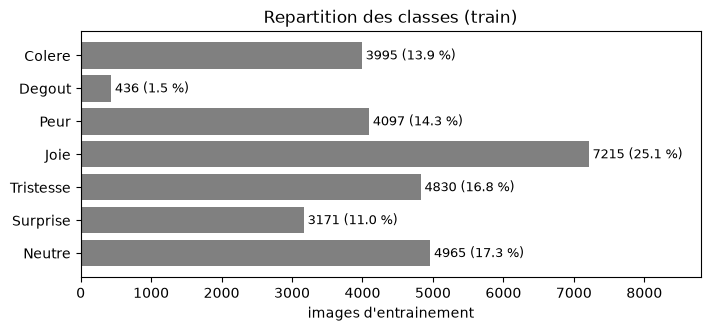

In [5]:
ORIGINAL = {   # effectifs du fer2013.csv d'origine, dans l'ordre de CLASSES
    "train": [3995, 436, 4097, 7215, 4830, 3171, 4965],
    "val":   [467, 56, 496, 895, 653, 415, 607],
    "test":  [491, 55, 528, 879, 594, 416, 626],
}
for nom, yy in [("train", y_tr), ("val", y_va), ("test", y_te)]:
    obtenu = np.bincount(yy, minlength=7).tolist()
    print(f"{nom:5s} {obtenu} ->", "identique a l'original" if obtenu == ORIGINAL[nom] else "DIFFERENT")

effectifs = pd.DataFrame({k: np.bincount(v, minlength=7) for k, v in [("train", y_tr), ("validation", y_va), ("test", y_te)]},
                         index=CLASSES)
effectifs["total"] = effectifs.sum(axis=1)
effectifs["% du train"] = (100 * effectifs["train"] / effectifs["train"].sum()).round(1)
display(effectifs)
print(f"desequilibre : {effectifs['train'].max() / effectifs['train'].min():.1f} fois plus de 'Joie' que de 'Degout' dans le train")

plt.figure(figsize=(8, 3.2))
plt.barh(CLASSES[::-1], effectifs["train"][::-1], color="gray")
for i, v in enumerate(effectifs["train"][::-1]):
    plt.text(v + 50, i, f"{v} ({100 * v / effectifs['train'].sum():.1f} %)", va="center", fontsize=9)
plt.xlabel("images d'entrainement"); plt.xlim(0, 8800)
plt.title("Repartition des classes (train)")
plt.show()

**Ce qu'il faut retenir.**

- 35 887 images de 48×48 pixels, en niveaux de gris (un seul canal), stockées en PNG ; chaque pixel est un entier entre 0 et 255.
- 7 classes : colère, dégoût, peur, joie, tristesse, surprise, neutre.
- **Déséquilibre fort** : la joie représente 25 % du train, le dégoût 1,5 % (16,5 fois moins). Conséquences : l'accuracy seule sera trompeuse (on suivra aussi la macro-F1 et le rappel par classe), et un modèle qui répond toujours "Joie" a déjà 24,5 % d'accuracy sur le test. C'est le vrai plancher, pas les 14 % du hasard.

Quelques exemples par classe :

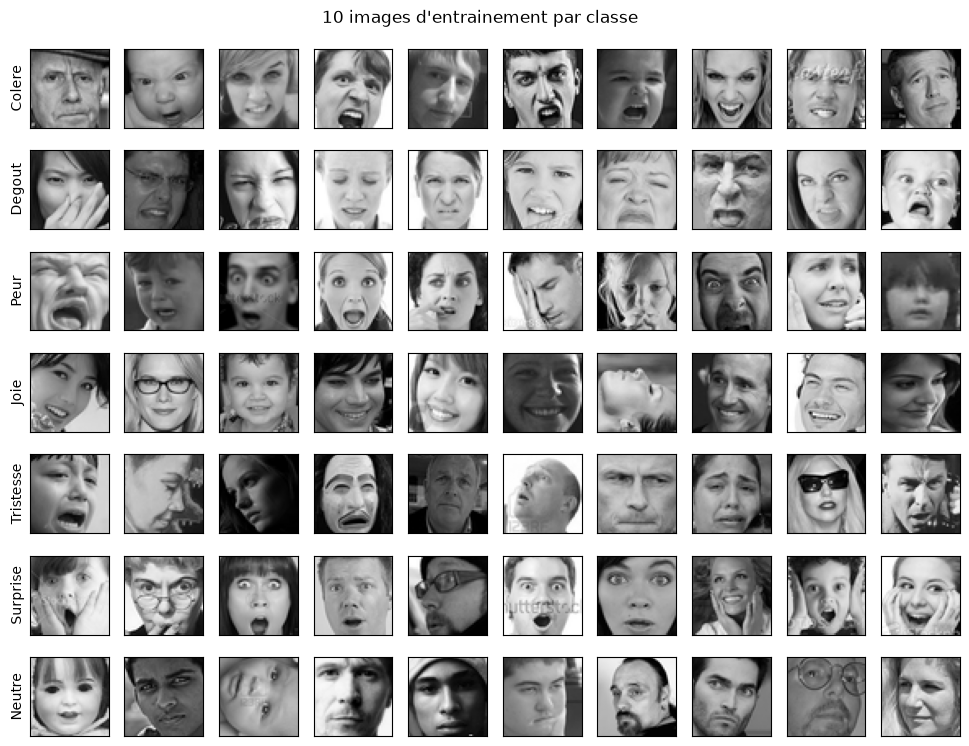

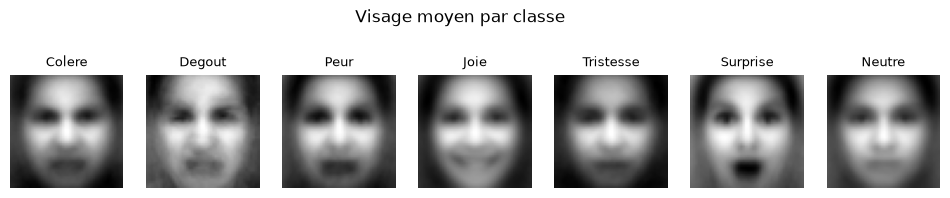

In [6]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(7, 10, figsize=(12, 9))
for c in range(7):
    for k, i in enumerate(rng.choice(np.where(y_tr == c)[0], 10, replace=False)):
        axes[c, k].imshow(x8_tr[i], cmap="gray", vmin=0, vmax=255)
        axes[c, k].set_xticks([]); axes[c, k].set_yticks([])
    axes[c, 0].set_ylabel(CLASSES[c], fontsize=10)
plt.suptitle("10 images d'entrainement par classe", y=0.92)
plt.show()

# visage moyen de chaque classe : les visages sont a peu pres alignes (yeux en haut, bouche en bas)
fig, axes = plt.subplots(1, 7, figsize=(12, 2.2))
for c, ax in enumerate(axes):
    ax.imshow(x8_tr[y_tr == c].mean(0), cmap="gray"); ax.set_title(CLASSES[c], fontsize=9); ax.axis("off")
plt.suptitle("Visage moyen par classe", y=1.05)
plt.show()

On voit déjà les difficultés : des visages de face mais aussi de trois quarts, des enfants et des personnes âgées, des filigranes de banques d'images, des mains devant le visage, et des expressions ambiguës (certaines "peurs" ressemblent à de la surprise, certaines "tristesses" à du neutre). Le visage moyen montre que les images sont à peu près alignées : les yeux et la bouche tombent toujours dans les mêmes zones. Ce cadrage sera important en partie 8, quand ce sera à nous de recadrer les visages trouvés par YOLO.

### 1.3 Préparation des données

| Étape | Ce qu'on fait | Pourquoi |
|---|---|---|
| Redimensionnement | rien ici : toutes les images font déjà 48×48 | un réseau attend une taille d'entrée fixe. En partie 8, chaque visage détecté sera ramené à 48×48 |
| Canal | (N, 48, 48) → (N, 48, 48, 1) | les couches de convolution attendent un axe "canaux" (1 en gris, 3 en couleur) |
| Normalisation | pixels divisés par 255 → valeurs dans [0, 1] | des entrées de l'ordre de 1 gardent les activations et les gradients dans une plage raisonnable ; avec des valeurs jusqu'à 255, les premiers pas de gradient seraient énormes et l'entraînement instable |
| Labels | entiers de 0 à 6 | c'est le format du fichier ; `CLASSES[k]` donne le nom |
| Encodage | pas de one-hot : on utilise la perte `sparse_categorical_crossentropy` | elle prend directement l'entier 3 au lieu du vecteur [0,0,0,1,0,0,0]. C'est exactement le même calcul, sans stocker 7 nombres par image |
| Train / validation / test | découpage officiel : 28 709 / 3 589 / 3 589 | le train sert à apprendre les poids, la validation à tous les réglages (early stopping, choix entre expériences, seuils), le **test uniquement à la mesure finale**, une seule fois, à la fin de la partie 6 |

In [7]:
def preparer(x8):
    # uint8 dans [0, 255] -> float32 dans [0, 1], plus un axe "canal" : (N, 48, 48) -> (N, 48, 48, 1)
    return (x8.astype("float32") / 255)[..., None]

x_tr, x_va, x_te = preparer(x8_tr), preparer(x8_va), preparer(x8_te)
if RAPIDE:
    x_tr, y_tr, x_va, y_va, x_te, y_te = x_tr[:3000], y_tr[:3000], x_va[:600], y_va[:600], x_te[:600], y_te[:600]

print("entree du reseau :", x_tr.shape, x_tr.dtype, "| min", x_tr.min(), "| max", x_tr.max())
print("5 premiers labels :", y_tr[:5], "->", [CLASSES[k] for k in y_tr[:5]])
print("le meme en one-hot (ce qu'on n'a pas besoin de stocker) :")
print(keras.utils.to_categorical(y_tr[:5], 7).astype(int))

entree du reseau : (28709, 48, 48, 1) float32 | min 0.0 | max 1.0
5 premiers labels : [0 0 2 4 6] -> ['Colere', 'Colere', 'Peur', 'Tristesse', 'Neutre']
le meme en one-hot (ce qu'on n'a pas besoin de stocker) :
[[1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1]]


## 2. Modèle de référence : un réseau dense

Avant le CNN, on entraîne un réseau "classique" entièrement connecté. Il ne sera pas bon : il sert de point de comparaison, pour mesurer ce que les convolutions apportent vraiment.

> image 48×48 → Flatten (2 304 valeurs) → Dense 512 + ReLU → Dense 256 + ReLU → Dense 7 + Softmax

**Comment l'image entre dans le réseau.** `Flatten` met les 48 × 48 = 2 304 pixels bout à bout dans un vecteur. Le réseau perd toute notion de voisinage : pour lui, le pixel (10, 10) et le pixel (10, 11) sont deux entrées sans lien. C'est la faiblesse qu'on cherche à mettre en évidence.

**Poids et biais.** Chaque neurone d'une couche Dense calcule une somme pondérée de toutes ses entrées, plus un biais : z = w₁x₁ + … + wₙxₙ + b. Les poids disent quelle importance donner à chaque entrée, le biais décale le seuil d'activation. Ce sont ces nombres que l'entraînement ajuste. Une couche Dense de n entrées vers m neurones a n × m poids et m biais.

**Propagation avant.** On applique les couches l'une après l'autre : h₁ = ReLU(x·W₁ + b₁), h₂ = ReLU(h₁·W₂ + b₂), z = h₂·W₃ + b₃, puis p = softmax(z). On le refait à la main plus bas pour vérifier.

**Fonctions d'activation.** Sans elles, empiler des couches ne servirait à rien : une suite de couches linéaires reste une fonction linéaire. **ReLU** (max(0, z)) est la plus utilisée : simple, et son gradient vaut 1 pour toute valeur positive, ce qui évite que le signal s'éteigne en traversant les couches. En sortie, **softmax** transforme les 7 scores (les *logits*) en probabilités positives qui somment à 1 : pᵢ = exp(zᵢ) / Σⱼ exp(zⱼ).

**Fonction de perte.** L'entropie croisée vaut −log(p de la vraie classe). Elle vaut 0 si le réseau donne 100 % à la bonne classe, et elle explose quand il est sûr de lui et se trompe. Elle est faite pour aller avec softmax : le gradient par rapport aux logits vaut simplement p − y (probabilités prédites moins le vecteur one-hot de la vraie classe).

**Rétropropagation et descente de gradient.** La rétropropagation calcule, avec la règle de dérivation en chaîne appliquée de la sortie vers l'entrée, la dérivée de la perte par rapport à chaque poids. La descente de gradient fait ensuite un petit pas dans la direction qui fait baisser la perte : w ← w − η · ∂L/∂w, où η est le *learning rate*. On le fait sur des lots de 64 images (descente de gradient stochastique par mini-lots). On utilise **Adam**, une descente de gradient qui adapte le pas de chaque poids en fonction de l'historique de ses gradients ; elle marche bien sans réglage fin (justification complète en partie 4).

**Sortie multiclasse.** 7 neurones, un par classe, avec softmax (et non 1 neurone avec sigmoïde, qui ne sert que pour 2 classes). La classe prédite est celle de plus forte probabilité.

In [8]:
def construire_dense():
    keras.utils.set_random_seed(SEED)   # memes poids initiaux a chaque execution
    entree = keras.Input(shape=(48, 48, 1), name="visage")
    h = layers.Flatten(name="flatten")(entree)
    h = layers.Dense(512, activation="relu", name="dense_1")(h)
    h = layers.Dense(256, activation="relu", name="dense_2")(h)
    sortie = layers.Dense(7, activation="softmax", name="sortie")(h)
    return keras.Model(entree, sortie, name="dense")

def detail_parametres(c):
    # le calcul du nombre de parametres de chaque couche, ecrit en clair
    if isinstance(c, layers.Conv2D):
        kh, kw, cin, f = c.kernel.shape
        return f"{kh}x{kw}x{cin}x{f} + {f} (poids + biais)" if c.use_bias else f"{kh}x{kw}x{cin}x{f}"
    if isinstance(c, layers.Dense):
        nin, nout = c.kernel.shape
        return f"{nin}x{nout} + {nout} (poids + biais)" if c.use_bias else f"{nin}x{nout}"
    if isinstance(c, layers.BatchNormalization):
        return f"4 x {c.gamma.shape[0]} (2 appris, 2 statistiques)"
    return ""

def tableau_couches(modele):
    lignes = [{"couche": c.name, "type": c.__class__.__name__, "dimension de sortie": str(tuple(c.output.shape[1:])),
               "parametres": c.count_params(), "calcul": detail_parametres(c)} for c in modele.layers]
    df = pd.DataFrame(lignes)
    df.loc[len(df)] = ["TOTAL", "", "", df["parametres"].sum(), ""]
    return df.set_index("couche")

dense = construire_dense()
display(tableau_couches(dense))

,type,dimension de sortie,parametres,calcul
couche,,,,
visage,InputLayer,"(48, 48, 1)",0,
flatten,Flatten,"(2304,)",0,
dense_1,Dense,"(512,)",1180160,2304x512 + 512 (poids + biais)
dense_2,Dense,"(256,)",131328,512x256 + 256 (poids + biais)
sortie,Dense,"(7,)",1799,256x7 + 7 (poids + biais)
TOTAL,,,1313287,


1,3 million de paramètres, dont 90 % dans la première couche : chaque neurone est relié aux 2 304 pixels. C'est beaucoup pour 28 709 images, ce qui laisse prévoir du surapprentissage.

Les fonctions d'entraînement ci-dessous servent pour tous les modèles du notebook. Les choix (perte, optimiseur, taille de lot, nombre d'epochs, early stopping) sont justifiés en partie 4.

In [9]:
class Journal(keras.callbacks.Callback):
    # une ligne courte par epoch, au lieu de la barre de progression de Keras
    def on_epoch_end(self, epoch, logs=None):
        print(f"epoch {epoch + 1:2d} | loss {logs['loss']:.3f}  acc {100 * logs['accuracy']:4.1f} % | "
              f"val_loss {logs['val_loss']:.3f}  val_acc {100 * logs['val_accuracy']:4.1f} % | lr {logs.get('learning_rate', 0):.1e}")

def augmentation_geometrique(x, rng, rot=10, dec=0.08, zoom=0.08):
    # miroir horizontal une fois sur deux, puis rotation (+-10 degres), decalage (+-8 %) et zoom (+-8 %) tires au hasard
    x = x.copy()
    miroir = rng.random(len(x)) < 0.5
    x[miroir] = x[miroir, :, ::-1]
    sortie = np.empty_like(x)
    c = np.array([23.5, 23.5])
    for i in range(len(x)):
        a = np.deg2rad(rng.uniform(-rot, rot))
        m = np.array([[np.cos(a), -np.sin(a)], [np.sin(a), np.cos(a)]]) / (1 + rng.uniform(-zoom, zoom))
        t = rng.uniform(-dec, dec, 2) * 48
        sortie[i, :, :, 0] = ndimage.affine_transform(x[i, :, :, 0], m, offset=c - m @ c - t, order=1, mode="reflect")
    return sortie

def degradations_aleatoires(x, rng):
    # experience E5 : ce que fait une vraie camera (luminosite et contraste, bruit du capteur, visage loin = basse resolution)
    x = x.copy()
    n = len(x)
    k = rng.random(n) < 0.5
    m = x[k].mean(axis=(1, 2, 3), keepdims=True)
    x[k] = ((x[k] - m) * rng.uniform(0.3, 1.0, (k.sum(), 1, 1, 1)) + m) * rng.uniform(0.25, 1.1, (k.sum(), 1, 1, 1))
    k = rng.random(n) < 0.3
    x[k] = x[k] + rng.normal(0, 1, x[k].shape) * rng.uniform(0, 0.1, (k.sum(), 1, 1, 1))
    for i in np.where(rng.random(n) < 0.3)[0]:
        r = int(rng.integers(12, 40))
        petit = cv2.resize(x[i, :, :, 0], (r, r), interpolation=cv2.INTER_AREA)
        x[i, :, :, 0] = cv2.resize(petit, (48, 48), interpolation=cv2.INTER_LINEAR)
    return np.clip(x, 0, 1).astype("float32")

class Flux(keras.utils.PyDataset):
    # fournit les lots d'entrainement dans un ordre different a chaque epoch ; l'augmentation est refaite a chaque fois,
    # donc le modele ne voit jamais deux fois exactement la meme image
    def __init__(self, x, y, geometrique=False, reelles=False, poids_classes=None, graine=SEED):
        super().__init__()
        self.x, self.y, self.geometrique, self.reelles = x, y, geometrique, reelles
        self.poids = None if poids_classes is None else np.asarray(poids_classes, "float32")
        self.rng = np.random.default_rng(graine)
        self.ordre = self.rng.permutation(len(x))
    def __len__(self):
        return math.ceil(len(self.x) / BATCH)
    def __getitem__(self, i):
        idx = self.ordre[i * BATCH:(i + 1) * BATCH]
        xb, yb = self.x[idx], self.y[idx]
        if self.geometrique:
            xb = augmentation_geometrique(xb, self.rng)
        if self.reelles:
            xb = degradations_aleatoires(xb, self.rng)
        return (xb, yb) if self.poids is None else (xb, yb, self.poids[yb])
    def on_epoch_end(self):
        self.ordre = self.rng.permutation(len(self.x))

def entrainer(modele, nom, geometrique=False, reelles=False, poids_classes=None, lr=1e-3, patience=8):
    chemin = os.path.join(DOSSIER_MODELES, f"{nom}.keras")
    chemin_h = os.path.join(DOSSIER_MODELES, f"{nom}_historique.json")
    if not REENTRAINER and os.path.exists(chemin) and os.path.exists(chemin_h):
        print(f"{nom} : deja entraine, recharge depuis {chemin}")
        with open(chemin_h) as f:
            return keras.models.load_model(chemin), json.load(f)
    keras.utils.set_random_seed(SEED)
    modele.compile(optimizer=keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    rappels = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
               keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
               Journal()]
    t0 = time.time()
    h = modele.fit(Flux(x_tr, y_tr, geometrique, reelles, poids_classes), validation_data=(x_va, y_va),
                   validation_batch_size=512, epochs=EPOCHS_MAX, callbacks=rappels, verbose=0)
    hist = {k: [float(v) for v in vals] for k, vals in h.history.items()}
    hist["duree_min"] = (time.time() - t0) / 60
    hist["meilleure_epoch"] = int(np.argmin(hist["val_loss"])) + 1
    modele.save(chemin)
    with open(chemin_h, "w") as f:
        json.dump(hist, f)
    print(f"{nom} : {len(hist['loss'])} epochs en {hist['duree_min']:.1f} min, poids gardes : epoch {hist['meilleure_epoch']}")
    return modele, hist

def courbes(hist, titre):
    ep = range(1, len(hist["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    axes[0].plot(ep, hist["loss"], label="train"); axes[0].plot(ep, hist["val_loss"], label="validation")
    axes[1].plot(ep, [100 * a for a in hist["accuracy"]], label="train")
    axes[1].plot(ep, [100 * a for a in hist["val_accuracy"]], label="validation")
    for ax, t in zip(axes, ["loss (entropie croisee)", "accuracy (%)"]):
        ax.axvline(hist["meilleure_epoch"], color="gray", ls=":", label="poids gardes")
        ax.set_title(t); ax.set_xlabel("epoch"); ax.legend(fontsize=8)
    plt.suptitle(titre); plt.show()

def predire(modele, x):
    return np.asarray(modele.predict(x, batch_size=512, verbose=0))

def scores(modele, x, y):
    pred = predire(modele, x).argmax(1)
    return {"accuracy %": 100 * np.mean(pred == y), "balanced accuracy %": 100 * balanced_accuracy_score(y, pred),
            "macro F1 %": 100 * f1_score(y, pred, average="macro")}

epoch  1 | loss 1.816  acc 27.6 % | val_loss 1.695  val_acc 35.1 % | lr 1.0e-03


epoch  2 | loss 1.696  acc 33.1 % | val_loss 1.650  val_acc 36.1 % | lr 1.0e-03


epoch  3 | loss 1.661  acc 35.0 % | val_loss 1.633  val_acc 35.8 % | lr 1.0e-03


epoch  4 | loss 1.634  acc 36.0 % | val_loss 1.628  val_acc 37.0 % | lr 1.0e-03


epoch  5 | loss 1.621  acc 36.5 % | val_loss 1.634  val_acc 36.9 % | lr 1.0e-03


...

epoch 25 | loss 1.365  acc 47.4 % | val_loss 1.513  val_acc 41.5 % | lr 2.5e-04


epoch 26 | loss 1.359  acc 47.9 % | val_loss 1.515  val_acc 40.7 % | lr 2.5e-04


epoch 27 | loss 1.356  acc 47.7 % | val_loss 1.517  val_acc 41.0 % | lr 2.5e-04


epoch 28 | loss 1.340  acc 48.8 % | val_loss 1.518  val_acc 41.4 % | lr 1.3e-04


epoch 29 | loss 1.337  acc 48.7 % | val_loss 1.512  val_acc 41.0 % | lr 1.3e-04
dense : 29 epochs en 2.2 min, poids gardes : epoch 21


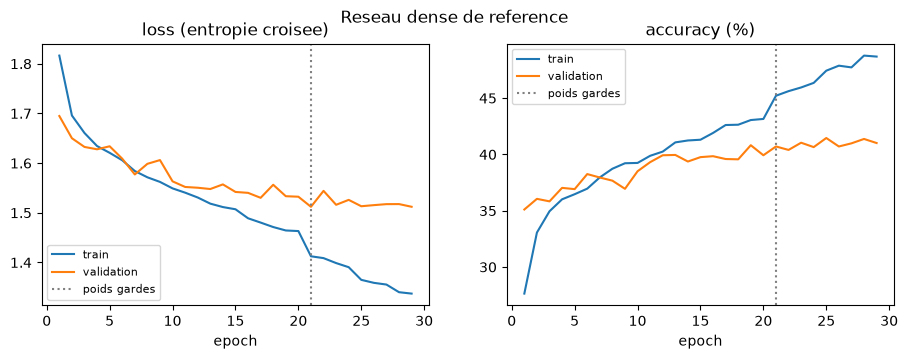

validation : {'accuracy %': 40.7, 'balanced accuracy %': 32.6, 'macro F1 %': 32.2}


In [10]:
dense, hist_dense = entrainer(dense, "dense")
courbes(hist_dense, "Reseau dense de reference")
print("validation :", {k: round(float(v), 1) for k, v in scores(dense, x_va, y_va).items()})

**Vérification de la propagation avant.** On refait à la main, avec numpy et les poids appris, le calcul que fait le réseau pour une image, et on compare avec Keras.

In [11]:
W1, b1 = dense.get_layer("dense_1").get_weights()
W2, b2 = dense.get_layer("dense_2").get_weights()
W3, b3 = dense.get_layer("sortie").get_weights()
x = x_va[0].reshape(-1)                 # Flatten : (48, 48, 1) -> 2304 valeurs
h1 = np.maximum(0, x @ W1 + b1)          # Dense 512 + ReLU
h2 = np.maximum(0, h1 @ W2 + b2)         # Dense 256 + ReLU
z = h2 @ W3 + b3                         # 7 logits
p = np.exp(z - z.max()); p /= p.sum()    # softmax (on retire le max pour eviter un depassement de capacite, ca ne change rien)
print("dimensions :", x.shape, "->", h1.shape, "->", h2.shape, "->", z.shape)
print("logits      :", np.round(z, 2))
print("a la main   :", np.round(p, 4), "| somme =", round(float(p.sum()), 4))
print("Keras       :", np.round(predire(dense, x_va[:1])[0], 4))
print(f"prediction : {CLASSES[p.argmax()]} ({100 * p.max():.0f} %) | vraie classe : {CLASSES[y_va[0]]}")

dimensions : (2304,) -> (512,) -> (256,) -> (7,)
logits      : [-0.23 -1.84  0.83 -0.53  0.25 -0.51  0.56]
a la main   : [0.1063 0.0212 0.307  0.0787 0.1716 0.0805 0.2346] | somme = 1.0
Keras       : [0.1063 0.0212 0.307  0.0787 0.1716 0.0805 0.2346]
prediction : Peur (31 %) | vraie classe : Colere


**Lecture.** Le réseau dense plafonne à 40,7 % en validation (balanced accuracy 32,6 %). C'est mieux que « toujours Joie » (24,5 %), donc il a appris quelque chose, mais il reste loin derrière. Les courbes montrent une montée lente et régulière, avec un train à peine au-dessus de la validation (45 % contre 41 % à l'epoch retenue) : ce n'est pas du surapprentissage, c'est une limite du modèle. En mettant les pixels bout à bout, il perd la structure de l'image : un sourire décalé de deux pixels active des entrées complètement différentes.

La vérification à la main montre que la propagation avant n'a rien de magique : trois produits matriciels, deux ReLU et un softmax redonnent exactement les probabilités calculées par Keras.

## 3. Construction d'un CNN

### 3.1 Les briques d'un réseau convolutif

**Filtre et convolution.** Un filtre est une petite grille de poids, ici 3×3. On le fait glisser sur l'image ; à chaque position, on multiplie les 9 pixels sous le filtre par les 9 poids et on additionne (plus un biais). Le même filtre est utilisé partout dans l'image : un détecteur de "coin de bouche relevé" marche où que soit la bouche, et il ne coûte que 9 poids au lieu des 2 304 d'un neurone dense.

**Feature map.** Le résultat d'un filtre sur toute l'image est une carte (*feature map*) qui vaut fort là où le motif du filtre est présent. Une couche de 32 filtres produit 32 cartes. Les filtres de la première couche apprennent des motifs simples (bords, contrastes) ; les couches suivantes combinent ces cartes en motifs de plus en plus complexes (un œil, un sourcil froncé, une bouche ouverte).

**Taille du kernel.** 3×3 partout. Deux convolutions 3×3 à la suite "voient" une zone de 5×5, comme un filtre 5×5, avec moins de poids (18 contre 25 par canal) et une non-linéarité de plus entre les deux. C'est le choix de VGG (Simonyan et Zisserman, 2015).

**Stride.** Le pas du glissement. Stride 1 : on décale le filtre d'un pixel à la fois. Stride 2 : de deux pixels, la sortie est deux fois plus petite. On garde 1 dans les convolutions et on laisse le pooling réduire la taille.

**Padding.** Sans bordure (`valid`), un filtre 3×3 ne peut pas se centrer sur les pixels du bord et l'image perd un pixel de chaque côté (48 → 46). Avec `same`, on ajoute une bordure de zéros pour garder 48×48 : on contrôle ainsi la taille uniquement avec le pooling, et les bords du visage (front, menton) restent couverts.

Taille de sortie : n_sortie = ⌊(n + 2p − k) / s⌋ + 1, avec n la taille d'entrée, k le kernel, s le stride, p le padding.

**ReLU** après chaque convolution, pour la non-linéarité (voir partie 2).

**Pooling.** Le max-pooling 2×2 garde le maximum de chaque carré de 2×2 pixels : la carte est divisée par deux dans chaque direction. Ça réduit le calcul, ça agrandit la zone de l'image que "voit" chaque neurone suivant, et ça rend le réseau un peu tolérant aux petits décalages (le maximum reste le même si le motif bouge d'un pixel).

**Flatten** met les cartes finales bout à bout pour les donner à la partie classification. **Dense** combine toutes ces caractéristiques. **La couche de sortie** a 7 neurones avec softmax.

Démonstration sur un vrai visage, avec des filtres écrits à la main (dans le CNN, ce sont des filtres appris) :

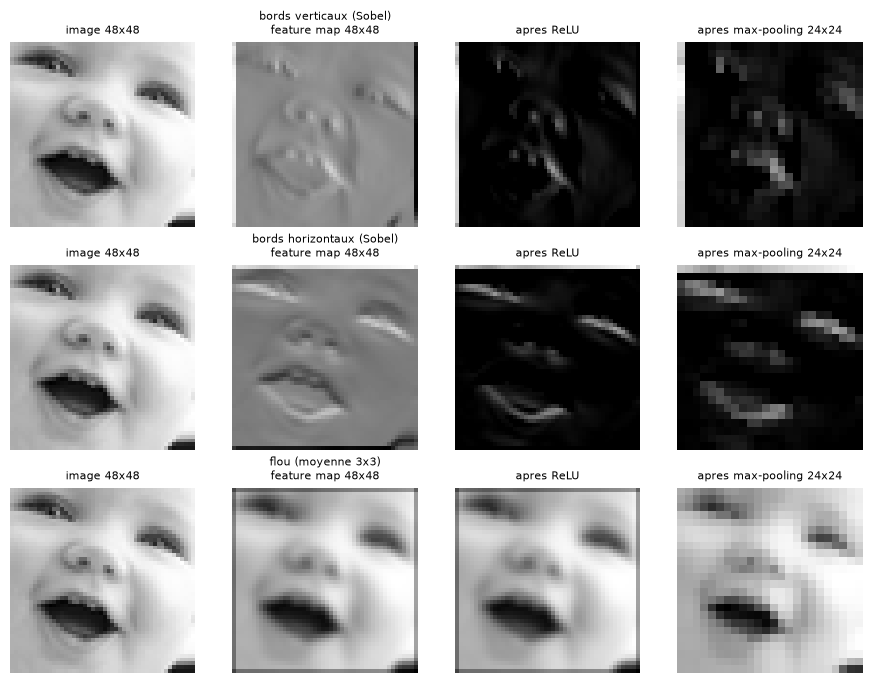

,entree,k,s,p,sortie
operation,,,,,
"Conv 3x3, stride 1, padding 'valid'",48,3,1,0,46
"Conv 3x3, stride 1, padding 'same'",48,3,1,1,48
"Conv 3x3, stride 2, padding 'same'",48,3,2,1,24
"Conv 5x5, stride 1, padding 'same'",48,5,1,2,48
"MaxPooling 2x2, stride 2",48,2,2,0,24


In [12]:
visage = x_va[np.where(y_va == 3)[0][2], :, :, 0]
filtres = {
    "bords verticaux (Sobel)": np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], "float32"),
    "bords horizontaux (Sobel)": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], "float32"),
    "flou (moyenne 3x3)": np.ones((3, 3), "float32") / 9,
}
fig, axes = plt.subplots(3, 4, figsize=(11, 8.2))
for r, (nom, k) in enumerate(filtres.items()):
    carte = ndimage.correlate(visage, k, mode="constant")     # ce que calcule Conv2D (padding "same")
    activee = np.maximum(carte, 0)                              # ReLU
    poolee = activee.reshape(24, 2, 24, 2).max(axis=(1, 3))     # max-pooling 2x2
    for c, (im, t) in enumerate([(visage, "image 48x48"), (carte, f"{nom}\nfeature map 48x48"),
                                 (activee, "apres ReLU"), (poolee, "apres max-pooling 24x24")]):
        axes[r, c].imshow(im, cmap="gray"); axes[r, c].set_title(t, fontsize=8); axes[r, c].axis("off")
plt.show()

taille = lambda n, k, s, p: (n + 2 * p - k) // s + 1
display(pd.DataFrame([
    {"operation": "Conv 3x3, stride 1, padding 'valid'", "entree": 48, "k": 3, "s": 1, "p": 0, "sortie": taille(48, 3, 1, 0)},
    {"operation": "Conv 3x3, stride 1, padding 'same'", "entree": 48, "k": 3, "s": 1, "p": 1, "sortie": taille(48, 3, 1, 1)},
    {"operation": "Conv 3x3, stride 2, padding 'same'", "entree": 48, "k": 3, "s": 2, "p": 1, "sortie": taille(48, 3, 2, 1)},
    {"operation": "Conv 5x5, stride 1, padding 'same'", "entree": 48, "k": 5, "s": 1, "p": 2, "sortie": taille(48, 5, 1, 2)},
    {"operation": "MaxPooling 2x2, stride 2", "entree": 48, "k": 2, "s": 2, "p": 0, "sortie": taille(48, 2, 2, 0)},
]).set_index("operation"))

### 3.2 Notre architecture

> image 48×48×1 → [Conv 3×3 → ReLU → Conv 3×3 → ReLU → MaxPool 2×2] × 3 blocs (32, 64 puis 128 filtres) → Flatten → Dense 256 + ReLU → Dense 7 + Softmax

Justification des choix :

- **Trois blocs** : 48 → 24 → 12 → 6. Après trois poolings, chaque neurone de la dernière carte dépend d'une zone d'environ 36×36 pixels de l'image (champ récepteur), assez pour relier un sourcil à la bouche. Un quatrième bloc donnerait des cartes 3×3, trop petites pour garder la position des éléments du visage.
- **Deux convolutions par bloc**, pour la raison donnée plus haut (zone 5×5 avec moins de poids).
- **Nombre de filtres doublé à chaque bloc** (32, 64, 128) pendant que la taille est divisée par deux : il y a plus de motifs complexes possibles (une expression) que de motifs simples (un bord), et le coût de calcul reste équilibré entre les blocs.
- **Dense 256** pour combiner les 4 608 caractéristiques finales avant la décision.
- Cette première version n'a **aucune régularisation** (ni dropout, ni batch normalization, ni augmentation). C'est volontaire : on part du plus simple, on regarde ce qui ne va pas, et on ajoute les corrections une par une en partie 6 pour mesurer l'effet de chacune.

Évolution des dimensions et nombre de paramètres, couche par couche :

In [13]:
def construire_cnn(filtres=(32, 64, 128), dense=256, dropout=False, batchnorm=False, nom="cnn"):
    keras.utils.set_random_seed(SEED)
    entree = keras.Input(shape=(48, 48, 1), name="visage")
    h = entree
    for b, f in enumerate(filtres, start=1):
        for k in (1, 2):
            # avec batch normalization juste apres, le biais de la convolution ne sert a rien (la BN a le sien)
            h = layers.Conv2D(f, 3, padding="same", use_bias=not batchnorm, name=f"bloc{b}_conv{k}")(h)
            if batchnorm:
                h = layers.BatchNormalization(name=f"bloc{b}_bn{k}")(h)
            h = layers.Activation("relu", name=f"bloc{b}_relu{k}")(h)
        h = layers.MaxPooling2D(2, name=f"bloc{b}_pool")(h)
        if dropout:
            h = layers.Dropout(0.25, name=f"bloc{b}_dropout")(h)
    h = layers.Flatten(name="flatten")(h)
    h = layers.Dense(dense, use_bias=not batchnorm, name="dense")(h)
    if batchnorm:
        h = layers.BatchNormalization(name="dense_bn")(h)
    h = layers.Activation("relu", name="dense_relu")(h)
    if dropout:
        h = layers.Dropout(0.5, name="dense_dropout")(h)
    sortie = layers.Dense(7, activation="softmax", name="sortie")(h)
    return keras.Model(entree, sortie, name=nom)

cnn_v1 = construire_cnn(nom="cnn_v1")
display(tableau_couches(cnn_v1))

,type,dimension de sortie,parametres,calcul
couche,,,,
visage,InputLayer,"(48, 48, 1)",0,
bloc1_conv1,Conv2D,"(48, 48, 32)",320,3x3x1x32 + 32 (poids + biais)
bloc1_relu1,Activation,"(48, 48, 32)",0,
bloc1_conv2,Conv2D,"(48, 48, 32)",9248,3x3x32x32 + 32 (poids + biais)
bloc1_relu2,Activation,"(48, 48, 32)",0,
bloc1_pool,MaxPooling2D,"(24, 24, 32)",0,
bloc2_conv1,Conv2D,"(24, 24, 64)",18496,3x3x32x64 + 64 (poids + biais)
bloc2_relu1,Activation,"(24, 24, 64)",0,
bloc2_conv2,Conv2D,"(24, 24, 64)",36928,3x3x64x64 + 64 (poids + biais)


Lecture du tableau :

- Une convolution de f filtres 3×3 sur c canaux a 3 × 3 × c × f poids + f biais. La première (1 canal, 32 filtres) n'a que 320 paramètres ; la dernière (128 → 128) en a 147 584.
- Les couches ReLU, MaxPooling et Flatten n'ont aucun paramètre : elles transforment les données sans rien apprendre.
- Les convolutions ne pèsent que 286 000 paramètres au total. La couche Dense après le Flatten en a 1,18 million (4 608 × 256 + 256) : 80 % du réseau. C'est elle qui risque le plus de surapprendre, d'où le dropout placé juste avant la sortie dans les expériences.
- Le CNN a à peu près autant de paramètres que le réseau dense (1,47 contre 1,31 million), mais il les utilise beaucoup mieux : la comparaison des deux est donc équitable.

## 4. Entraînement

| Choix | Valeur | Justification |
|---|---|---|
| Fonction de perte | entropie croisée (`sparse_categorical_crossentropy`) | c'est la perte standard d'une classification multiclasse avec softmax : elle pénalise fortement une erreur commise avec assurance, et son gradient est simple (p − y). La version *sparse* prend les labels entiers directement |
| Optimiseur | Adam, learning rate 10⁻³ | Adam adapte le pas de chaque poids selon la moyenne et la variance de ses gradients récents ; il converge vite et marche bien sans réglage. 10⁻³ est sa valeur par défaut, qu'on divise par 2 quand la validation stagne (`ReduceLROnPlateau`) pour affiner en fin d'entraînement |
| Taille de lot | 64 | 449 mises à jour par epoch. Un lot plus petit donne un gradient trop bruité et sous-utilise le GPU ; un lot plus gros fait moins de mises à jour par epoch et généralise souvent un peu moins bien. 32 à 128 est la plage habituelle pour ce type de réseau |
| Nombre d'epochs | fixé par l'**early stopping** (plafond de 80) | on arrête quand la loss de validation ne s'améliore plus depuis 8 epochs, et on revient aux poids de la meilleure epoch. Le nombre d'epochs n'est donc pas choisi à la main : il est choisi par la validation, ce qui évite à la fois de s'arrêter trop tôt et de surapprendre |
| Métriques | accuracy pendant l'entraînement ; puis macro-F1, balanced accuracy et rappel par classe | l'accuracy est la métrique demandée et la plus parlante, mais avec 1,5 % de dégoût elle peut rester bonne même si cette classe n'est jamais reconnue. La macro-F1 et la balanced accuracy donnent le même poids à chaque classe |

On entraîne le CNN v1 :

epoch  1 | loss 1.752  acc 28.4 % | val_loss 1.579  val_acc 39.2 % | lr 1.0e-03


epoch  2 | loss 1.479  acc 42.8 % | val_loss 1.371  val_acc 46.8 % | lr 1.0e-03


epoch  3 | loss 1.302  acc 49.9 % | val_loss 1.276  val_acc 51.2 % | lr 1.0e-03


epoch  4 | loss 1.166  acc 55.7 % | val_loss 1.176  val_acc 55.2 % | lr 1.0e-03


epoch  5 | loss 1.053  acc 60.5 % | val_loss 1.161  val_acc 56.5 % | lr 1.0e-03


...

epoch  9 | loss 0.405  acc 85.7 % | val_loss 1.685  val_acc 56.6 % | lr 5.0e-04


epoch 10 | loss 0.268  acc 90.8 % | val_loss 1.966  val_acc 56.7 % | lr 5.0e-04


epoch 11 | loss 0.179  acc 93.9 % | val_loss 2.388  val_acc 56.3 % | lr 5.0e-04


epoch 12 | loss 0.083  acc 97.7 % | val_loss 2.836  val_acc 55.9 % | lr 2.5e-04


epoch 13 | loss 0.051  acc 98.8 % | val_loss 3.182  val_acc 57.0 % | lr 2.5e-04
cnn_v1 : 13 epochs en 3.1 min, poids gardes : epoch 5


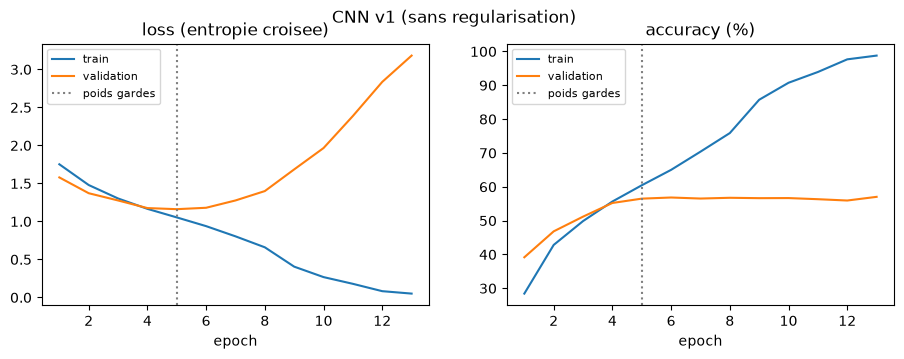

validation : {'accuracy %': 56.5, 'balanced accuracy %': 50.0, 'macro F1 %': 51.6}


train (meme taille, sans augmentation) : {'accuracy %': 67.6, 'balanced accuracy %': 61.3, 'macro F1 %': 63.3}


In [14]:
cnn_v1, hist_v1 = entrainer(cnn_v1, "cnn_v1")
courbes(hist_v1, "CNN v1 (sans regularisation)")
print("validation :", {k: round(float(v), 1) for k, v in scores(cnn_v1, x_va, y_va).items()})
idx_train_controle = np.random.default_rng(SEED).choice(len(x_tr), min(len(x_tr), 3589), replace=False)
print("train (meme taille, sans augmentation) :",
      {k: round(float(v), 1) for k, v in scores(cnn_v1, x_tr[idx_train_controle], y_tr[idx_train_controle]).items()})

**Lecture.** Le CNN v1 fait d'emblée beaucoup mieux que le réseau dense : 56,5 % en validation contre 40,7 %, avec à peu près le même nombre de paramètres. Les convolutions exploitent la structure de l'image : un même filtre reconnaît un motif où qu'il soit.

Mais les courbes montrent un surapprentissage massif. La loss de validation est minimale à l'epoch 5 (1,16), puis remonte jusqu'à 3,18 à l'epoch 13, pendant que la loss d'entraînement tombe à 0,05 et l'accuracy d'entraînement grimpe à 98,8 %. Le réseau apprend les 28 709 images par cœur, sans rien gagner sur des images nouvelles : la validation reste bloquée vers 56-57 %. L'early stopping a fait son travail en gardant les poids de l'epoch 5. Même à cette epoch, le train est à 67,6 % contre 56,5 % en validation. C'est le premier problème que les expériences de la partie 6 doivent régler.

## 5. Évaluation et analyse des erreurs

L'analyse se fait ici sur la **validation** : elle sert à comprendre ce qui ne va pas et à décider des expériences de la partie 6. Le test reste intact jusqu'à l'évaluation finale.

### 5.1 Performances par classe

,precision %,rappel %,F1 %,images,confondue surtout avec
Colere,41.5,53.1,46.6,467,Tristesse
Degout,73.3,19.6,31.0,56,Colere
Peur,43.5,34.9,38.7,496,Tristesse
Joie,74.6,80.1,77.3,895,Neutre
Tristesse,46.4,46.6,46.5,653,Colere
Surprise,77.7,66.5,71.7,415,Peur
Neutre,49.2,49.3,49.2,607,Tristesse


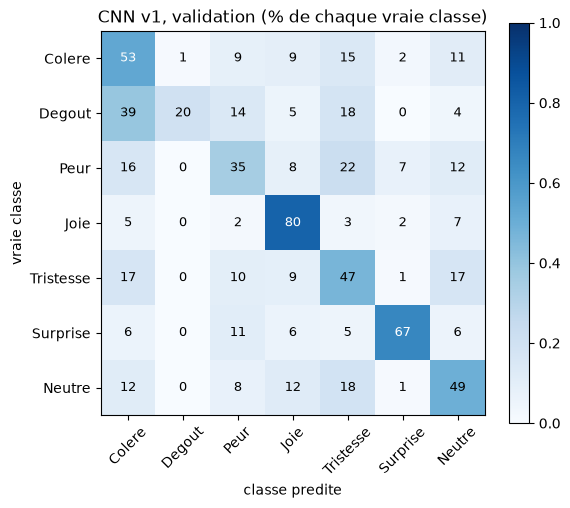

In [15]:
def tableau_par_classe(y, pred):
    r = classification_report(y, pred, labels=range(7), target_names=CLASSES, output_dict=True, zero_division=0)
    df = pd.DataFrame({c: r[c] for c in CLASSES}).T[["precision", "recall", "f1-score", "support"]]
    df[["precision", "recall", "f1-score"]] = (100 * df[["precision", "recall", "f1-score"]]).round(1)
    df = df.rename(columns={"precision": "precision %", "recall": "rappel %", "f1-score": "F1 %", "support": "images"})
    cm = confusion_matrix(y, pred, labels=range(7))
    np.fill_diagonal(cm, -1)
    df["confondue surtout avec"] = [CLASSES[k] for k in cm.argmax(1)]
    df["images"] = df["images"].astype(int)
    return df

def matrice_confusion(y, pred, titre):
    cm = confusion_matrix(y, pred, labels=range(7))
    cmn = cm / cm.sum(1, keepdims=True)
    plt.figure(figsize=(6.2, 5.2))
    plt.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for i in range(7):
        for j in range(7):
            plt.text(j, i, f"{100 * cmn[i, j]:.0f}", ha="center", va="center", fontsize=9,
                     color="white" if cmn[i, j] > 0.5 else "black")
    plt.xticks(range(7), CLASSES, rotation=45); plt.yticks(range(7), CLASSES)
    plt.xlabel("classe predite"); plt.ylabel("vraie classe"); plt.title(titre); plt.colorbar()
    plt.show()

p_va1 = predire(cnn_v1, x_va)
pred_va1 = p_va1.argmax(1)
display(tableau_par_classe(y_va, pred_va1))
matrice_confusion(y_va, pred_va1, "CNN v1, validation (% de chaque vraie classe)")

### 5.2 Exemples : image, vraie classe, classe prédite, probabilité

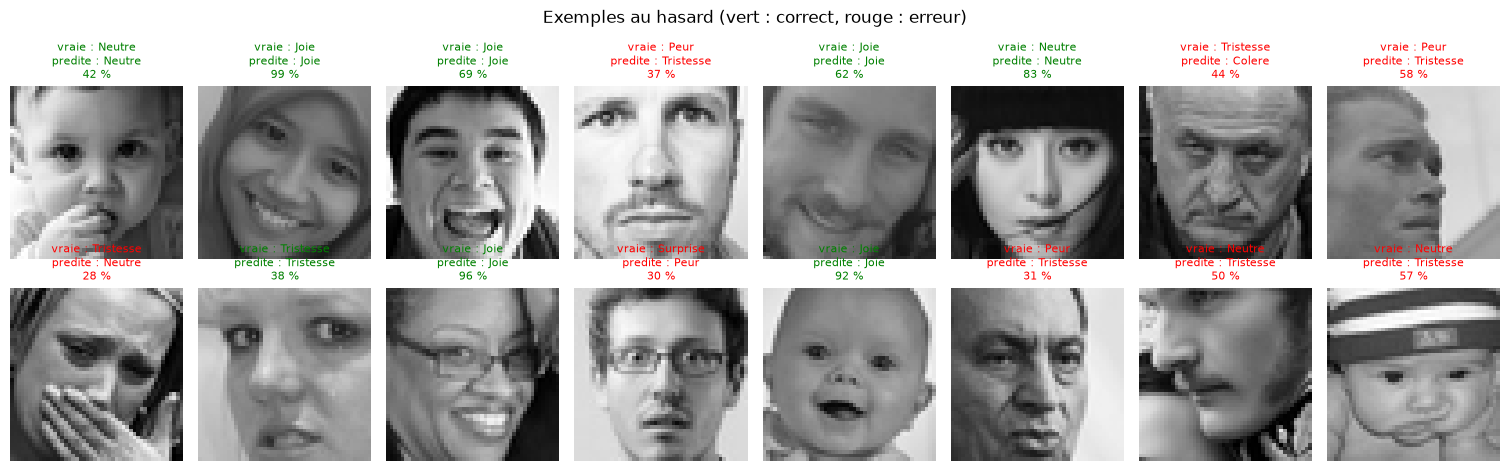

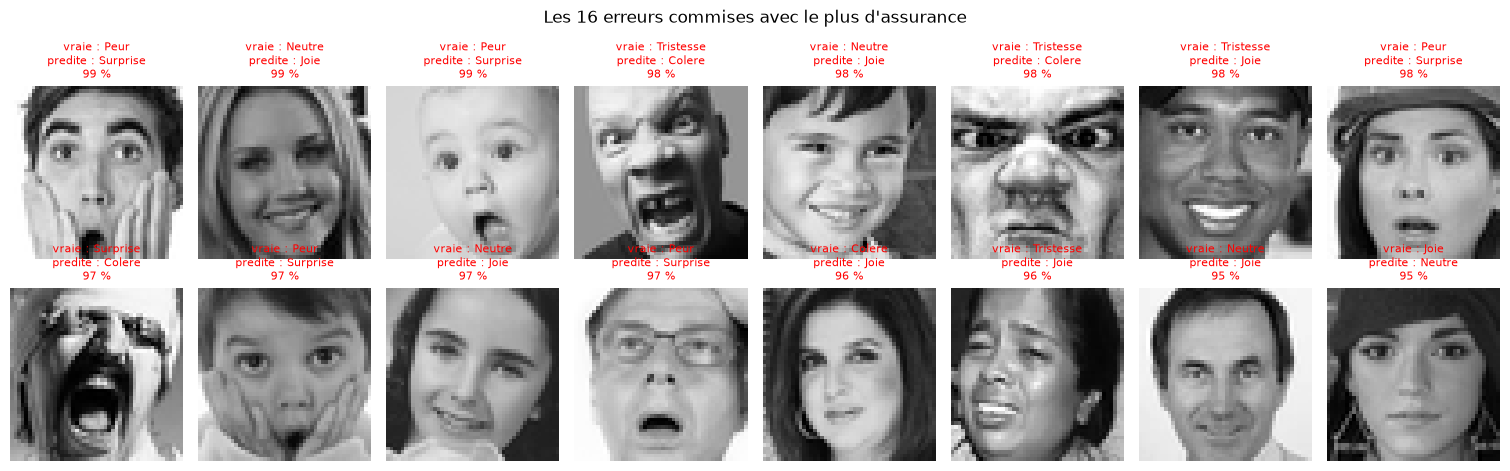

In [16]:
def montrer(x, y, p, indices, titre, colonnes=8):
    lignes = math.ceil(len(indices) / colonnes)
    fig, axes = plt.subplots(lignes, colonnes, figsize=(1.9 * colonnes, 2.35 * lignes))
    for ax in np.ravel(axes):
        ax.axis("off")
    for ax, i in zip(np.ravel(axes), indices):
        ok = p[i].argmax() == y[i]
        ax.imshow(x[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"vraie : {CLASSES[y[i]]}\npredite : {CLASSES[p[i].argmax()]}\n{100 * p[i].max():.0f} %",
                     fontsize=8, color="green" if ok else "red")
    plt.suptitle(titre, y=1.0)
    plt.tight_layout()
    plt.show()

rng = np.random.default_rng(1)
montrer(x_va, y_va, p_va1, rng.choice(len(x_va), 16, replace=False), "Exemples au hasard (vert : correct, rouge : erreur)")
erreurs = np.where(pred_va1 != y_va)[0]
montrer(x_va, y_va, p_va1, erreurs[np.argsort(-p_va1[erreurs].max(1))][:16], "Les 16 erreurs commises avec le plus d'assurance")

### 5.3 Erreur du modèle, ou erreur du label ?

Les erreurs les plus "sûres" ressemblent souvent à des erreurs d'étiquette plutôt qu'à des erreurs du modèle. Pour le vérifier, on utilise **FER+** (Barsoum et al., 2016) : Microsoft a fait réannoter chaque image de FER2013 par 10 personnes. Pour chaque erreur du modèle, on regarde si la majorité des 10 annotateurs FER+ dit la même chose que le modèle.

controle d'alignement : accord FER2013 / FER+ = 65.4 % (decale d'une ligne : 18.3 %)
labels de validation contredits par la majorite FER+ : 34.6 %
erreurs du CNN v1 ou la majorite FER+ donne la meme reponse que le modele : 26.8 %


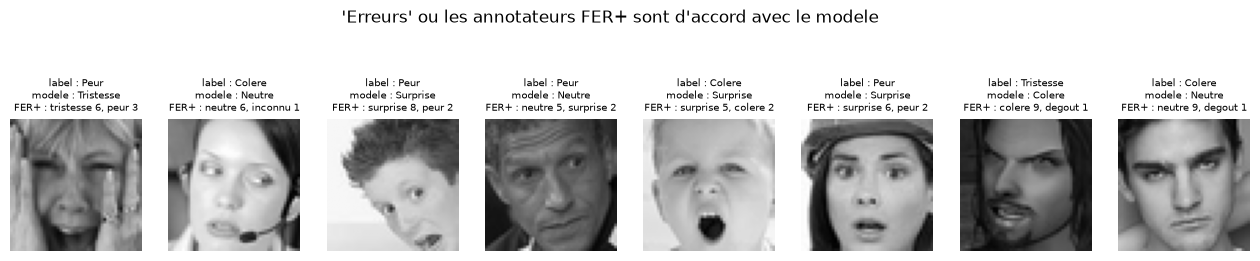

In [17]:
fp = pd.read_csv(telecharger(FERPLUS, "fer2013new.csv"))
VOTES = ["neutral", "happiness", "surprise", "sadness", "anger", "disgust", "fear", "contempt", "unknown", "NF"]
VERS_FER = {"anger": 0, "disgust": 1, "fear": 2, "happiness": 3, "sadness": 4, "surprise": 5, "neutral": 6}

def majorite_ferplus(usage, n):
    # label majoritaire des 10 annotateurs ; -1 si egalite en tete, ou si la majorite sort des 7 classes
    votes = fp[fp["Usage"] == usage][VOTES].to_numpy()[:n]
    gagnant = votes.argmax(1)
    lab = np.array([VERS_FER.get(VOTES[g], -1) for g in gagnant])
    tri = np.sort(votes, axis=1)
    lab[tri[:, -1] == tri[:, -2]] = -1
    return lab, votes

yfp_va, votes_va = majorite_ferplus("PublicTest", len(y_va))
yfp_te, votes_te = majorite_ferplus("PrivateTest", len(y_te))
ok = yfp_va >= 0
print(f"controle d'alignement : accord FER2013 / FER+ = {100 * np.mean(yfp_va[ok] == y_va[ok]):.1f} % "
      f"(decale d'une ligne : {100 * np.mean(yfp_va[ok][1:] == y_va[ok][:-1]):.1f} %)")
print(f"labels de validation contredits par la majorite FER+ : {100 * np.mean(yfp_va[ok] != y_va[ok]):.1f} %")
err = ok & (pred_va1 != y_va)
print(f"erreurs du CNN v1 ou la majorite FER+ donne la meme reponse que le modele : {100 * np.mean(pred_va1[err] == yfp_va[err]):.1f} %")

noms = ["neutre", "joie", "surprise", "tristesse", "colere", "degout", "peur", "mepris", "inconnu", "pas visage"]
sel = np.where(err & (pred_va1 == yfp_va))[0][:8]
fig, axes = plt.subplots(1, len(sel), figsize=(2 * len(sel), 3))
for ax, i in zip(np.atleast_1d(axes), sel):
    ax.imshow(x_va[i, :, :, 0], cmap="gray", vmin=0, vmax=1); ax.axis("off")
    top = np.argsort(votes_va[i])[::-1][:2]
    ax.set_title(f"label : {CLASSES[y_va[i]]}\nmodele : {CLASSES[pred_va1[i]]}\nFER+ : " +
                 ", ".join(f"{noms[t]} {votes_va[i][t]}" for t in top), fontsize=7)
plt.suptitle("'Erreurs' ou les annotateurs FER+ sont d'accord avec le modele", y=1.08)
plt.show()

**Lecture.** Les classes ne sont pas égales. La joie (rappel 80 %) et la surprise (67 %) sont bien reconnues : ce sont les expressions les plus marquées (sourire ; bouche ouverte et sourcils levés), et la joie est la classe la plus fréquente. La peur (35 %), la tristesse (47 %) et le neutre (49 %) se confondent entre elles. Le dégoût n'est trouvé qu'une fois sur cinq (20 %) : il n'a que 436 images d'entraînement, et le modèle le range presque toujours en colère. Sa précision est pourtant bonne (73 %) : quand le modèle dit « dégoût », il a souvent raison, mais il le dit très rarement.

Les confusions ont du sens : peur avec tristesse et surprise, colère avec tristesse, tristesse avec neutre. Ces expressions partagent des traits (sourcils froncés, bouche fermée) et les humains les confondent aussi. Les erreurs commises avec le plus d'assurance le montrent : plusieurs sont des visages dont le label paraît discutable.

FER+ le confirme. La majorité des 10 annotateurs FER+ contredit 34,6 % des labels de validation, et dans 26,8 % des erreurs du CNN v1, elle donne la même réponse que le modèle : une « peur » que 8 annotateurs sur 10 voient comme une surprise, une « colère » que 9 sur 10 voient neutre. Une partie de ce qu'on compte comme des erreurs n'en est pas.

Ce qu'on en tire pour la partie 6 : réduire le surapprentissage (dropout, batch normalization, augmentation) et s'occuper du dégoût (poids des classes).

## 6. Expériences et choix du modèle final

### 6.1 Plan d'expériences

Chaque expérience change **une seule chose** par rapport à une base, pour pouvoir attribuer l'effet observé à ce changement. Chacune répond à un problème vu en partie 4 ou 5, ou dans le notebook red team :

| | Changement | Base | Problème visé |
|---|---|---|---|
| E1 | + Dropout (25 % après chaque bloc, 50 % avant la sortie) | v1 | surapprentissage : le réseau apprend le train par cœur |
| E2 | + Batch normalization après chaque couche | E1 | entraînement plus stable ; permet d'aller plus loin sans diverger |
| E3 | + augmentation géométrique (miroir, rotation ±10°, décalage et zoom ±8 %) | E2 | trop peu de données : on fabrique des variantes plausibles de chaque visage |
| E4 | + poids des classes (racine de l'inverse de la fréquence) | E3 | le dégoût (1,5 % des images) est presque ignoré |
| E5 | + dégradations "conditions réelles" (luminosité, contraste, bruit, basse résolution) | E3 | la red team a mesuré que le modèle s'effondre avec une image de webcam (17,8 %) |

**Dropout** : à chaque lot, on éteint au hasard une partie des neurones. Le réseau ne peut plus compter sur un neurone précis ; il doit répartir l'information, ce qui l'empêche de mémoriser. Le dropout est désactivé en prédiction. **Batch normalization** : on recentre et on remet à l'échelle les activations de chaque couche sur le lot, puis on laisse le réseau réapprendre une moyenne et un écart-type. Les couches suivantes reçoivent des entrées de distribution stable, l'optimisation est plus facile, et le bruit lié au lot régularise un peu. **Augmentation** : chaque epoch voit une version légèrement différente de chaque visage (on n'augmente que le train ; un miroir ne change pas l'expression). **Poids des classes** : une erreur sur une image de dégoût compte environ 3 fois plus dans la perte qu'une erreur sur la joie. On prend la racine de l'inverse de la fréquence plutôt que l'inverse complet (×16) pour ne pas trop sacrifier les classes fréquentes.

### 6.2 Comment on mesure

Tout est mesuré sur la **validation** : accuracy, macro-F1, rappel du dégoût, écart entre train et validation (surapprentissage), et robustesse. Pour la robustesse, on reprend les dégradations du notebook red team, réécrites ici sans TensorFlow : bruit, basse résolution, et deux dégradations que E5 ne voit jamais à l'entraînement (flou et compression JPEG), plus le **scénario webcam** (cadrage imprécis, résolution un peu faible et bruit, chacun au niveau 2). Si E5 progresse aussi sur le flou et le JPEG, c'est une vraie généralisation, pas seulement l'apprentissage des dégradations vues.

**Règle de choix du modèle final, fixée avant de voir les résultats** : parmi les modèles à moins de 1,5 point de la meilleure accuracy de validation, on garde le plus robuste au scénario webcam. La démonstration se fait à la webcam : quelques dixièmes de point sur des images propres valent moins qu'un modèle qui tient en conditions réelles.

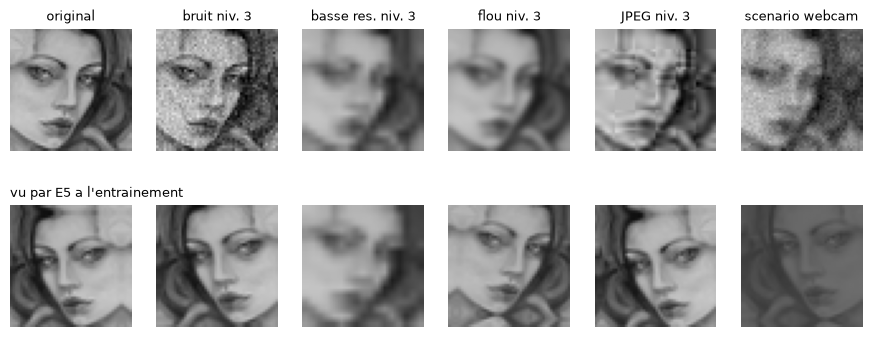

In [18]:
def quantifier(x):
    return (np.round(np.clip(x, 0, 1) * 255) / 255).astype("float32")   # comme une vraie image 8 bits

def bruit(x, s, rng):
    return x + rng.normal(0, [0.02, 0.04, 0.06, 0.09, 0.12][s - 1], x.shape)

def flou(x, s, rng):
    sigma = [0.5, 0.8, 1.1, 1.5, 2.0][s - 1]
    return ndimage.gaussian_filter(x, sigma=(0, sigma, sigma, 0))

def jpeg(x, s, rng):
    q = [40, 25, 15, 10, 6][s - 1]
    sortie = np.empty_like(x)
    for i, im in enumerate(x):
        tampon = io.BytesIO()
        Image.fromarray((np.clip(im[:, :, 0], 0, 1) * 255).round().astype("uint8")).save(tampon, "JPEG", quality=q)
        sortie[i, :, :, 0] = np.array(Image.open(tampon), dtype="float32") / 255
    return sortie

def basse_resolution(x, s, rng):
    r = [32, 24, 18, 14, 10][s - 1]
    return np.stack([cv2.resize(cv2.resize(im[:, :, 0], (r, r), interpolation=cv2.INTER_AREA), (48, 48),
                                interpolation=cv2.INTER_LINEAR) for im in x])[..., None]

def cadrage(x, s, rng):
    # boite de detection imprecise : centre decale et taille changee au hasard, jusqu'a +-a
    a = [0.05, 0.10, 0.15, 0.20, 0.25][s - 1]
    c = np.array([23.5, 23.5])
    sortie = np.empty_like(x)
    for i in range(len(x)):
        m = np.eye(2) * (1 + rng.uniform(-a, a))
        centre = c + 48 * rng.uniform(-a, a, 2)
        sortie[i, :, :, 0] = ndimage.affine_transform(x[i, :, :, 0], m, offset=centre - m @ c, order=1, mode="reflect")
    return sortie

def scenario_webcam(x):
    rng = np.random.default_rng(SEED)
    return quantifier(bruit(basse_resolution(cadrage(x, 2, rng), 2, rng), 2, rng))

def robustesse(modele, x, y):
    acc = lambda xx: 100 * np.mean(predire(modele, xx).argmax(1) == y)
    rng = lambda: np.random.default_rng(SEED)
    return {"bruit niv. 3 %": acc(quantifier(bruit(x, 3, rng()))),
            "basse resolution niv. 3 %": acc(quantifier(basse_resolution(x, 3, rng()))),
            "flou niv. 3 (jamais vu) %": acc(quantifier(flou(x, 3, rng()))),
            "JPEG niv. 3 (jamais vu) %": acc(quantifier(jpeg(x, 3, rng()))),
            "scenario webcam %": acc(scenario_webcam(x))}

# apercu des degradations et de ce que voit E5 pendant l'entrainement
ex = x_va[[7]]
fig, axes = plt.subplots(2, 6, figsize=(11, 4.2))
for ax, (t, im) in zip(axes[0], [("original", ex), ("bruit niv. 3", quantifier(bruit(ex, 3, np.random.default_rng(0)))),
                                 ("basse res. niv. 3", basse_resolution(ex, 3, None)), ("flou niv. 3", flou(ex, 3, None)),
                                 ("JPEG niv. 3", jpeg(ex, 3, None)), ("scenario webcam", scenario_webcam(ex))]):
    ax.imshow(im[0, :, :, 0], cmap="gray", vmin=0, vmax=1); ax.set_title(t, fontsize=9); ax.axis("off")
apercu = degradations_aleatoires(augmentation_geometrique(np.repeat(ex, 6, 0), np.random.default_rng(3)), np.random.default_rng(4))
for ax, im in zip(axes[1], apercu):
    ax.imshow(im[:, :, 0], cmap="gray", vmin=0, vmax=1); ax.axis("off")
axes[1, 0].set_title("vu par E5 a l'entrainement", fontsize=9, loc="left")
plt.show()

### 6.3 Les entraînements

In [19]:
freq = np.bincount(y_tr, minlength=7) / len(y_tr)
POIDS_CLASSES = np.sqrt(1 / (7 * freq))
print("poids des classes (E4) :", dict(zip(CLASSES, POIDS_CLASSES.round(2).tolist())))

EXPERIENCES = [
    # nom, changement, base, options du reseau, options d'entrainement
    ("E1_dropout", "+ dropout", "cnn_v1", dict(dropout=True), dict()),
    ("E2_batchnorm", "+ batch normalization", "E1_dropout", dict(dropout=True, batchnorm=True), dict()),
    ("E3_augmentation", "+ augmentation geometrique", "E2_batchnorm", dict(dropout=True, batchnorm=True), dict(geometrique=True)),
    ("E4_poids_classes", "+ poids des classes", "E3_augmentation", dict(dropout=True, batchnorm=True),
     dict(geometrique=True, poids_classes=POIDS_CLASSES)),
    ("E5_conditions_reelles", "+ degradations 'conditions reelles'", "E3_augmentation", dict(dropout=True, batchnorm=True),
     dict(geometrique=True, reelles=True)),
]
modeles = {"cnn_v1": cnn_v1}
historiques = {"cnn_v1": hist_v1}
for nom, changement, base, opt_reseau, opt_entrainement in EXPERIENCES:
    print(f"\n=== {nom} : {changement} (base : {base}) ===")
    modeles[nom], historiques[nom] = entrainer(construire_cnn(nom=nom, **opt_reseau), nom, **opt_entrainement)

poids des classes (E4) : {'Colere': 1.01, 'Degout': 3.07, 'Peur': 1.0, 'Joie': 0.75, 'Tristesse': 0.92, 'Surprise': 1.14, 'Neutre': 0.91}

=== E1_dropout : + dropout (base : cnn_v1) ===


epoch  1 | loss 1.811  acc 24.8 % | val_loss 1.773  val_acc 26.6 % | lr 1.0e-03


epoch  2 | loss 1.667  acc 33.7 % | val_loss 1.494  val_acc 42.0 % | lr 1.0e-03


epoch  3 | loss 1.504  acc 41.9 % | val_loss 1.395  val_acc 47.2 % | lr 1.0e-03


epoch  4 | loss 1.405  acc 46.0 % | val_loss 1.304  val_acc 51.2 % | lr 1.0e-03


...

epoch 76 | loss 1.044  acc 60.4 % | val_loss 0.952  val_acc 65.2 % | lr 1.0e-05


epoch 77 | loss 1.040  acc 60.4 % | val_loss 0.951  val_acc 65.3 % | lr 1.0e-05


epoch 78 | loss 1.048  acc 60.2 % | val_loss 0.953  val_acc 65.3 % | lr 1.0e-05


epoch 79 | loss 1.047  acc 60.4 % | val_loss 0.951  val_acc 65.1 % | lr 1.0e-05


epoch 80 | loss 1.041  acc 60.8 % | val_loss 0.952  val_acc 65.1 % | lr 1.0e-05
E5_conditions_reelles : 80 epochs en 33.8 min, poids gardes : epoch 79


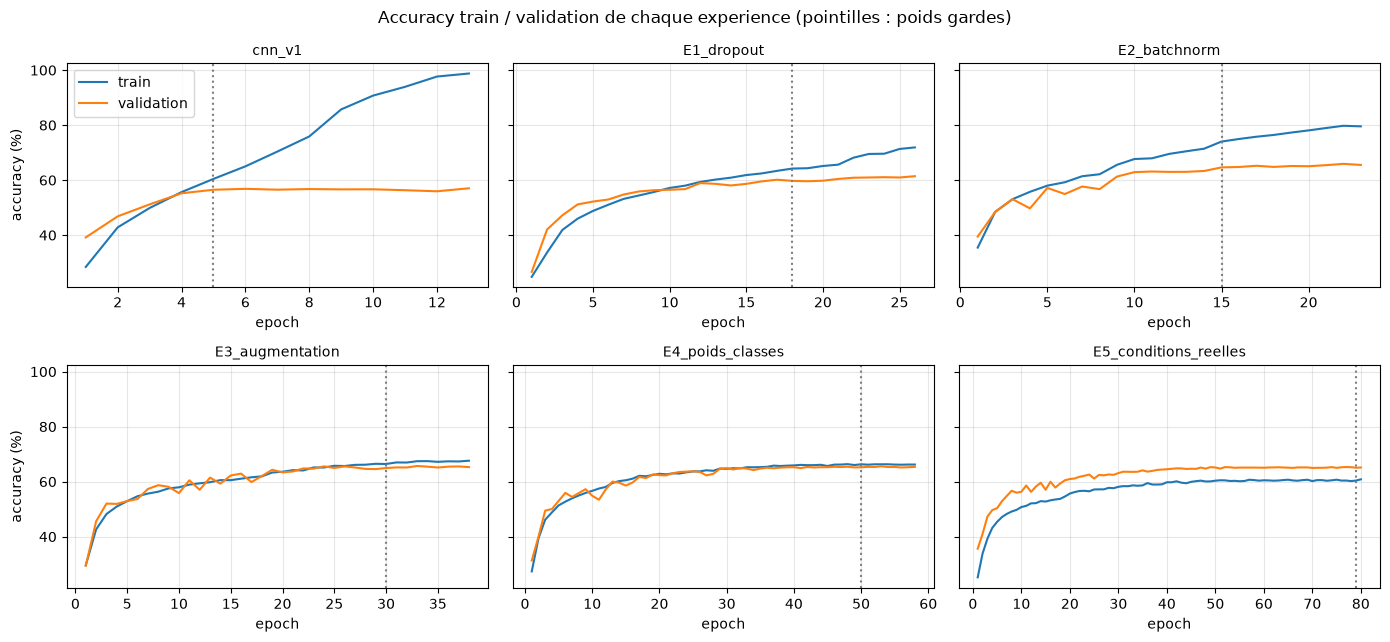

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharey=True)
for ax, nom in zip(axes.ravel(), historiques):
    h = historiques[nom]
    ep = range(1, len(h["accuracy"]) + 1)
    ax.plot(ep, [100 * a for a in h["accuracy"]], label="train")
    ax.plot(ep, [100 * a for a in h["val_accuracy"]], label="validation")
    ax.axvline(h["meilleure_epoch"], color="gray", ls=":")
    ax.set_title(nom, fontsize=10); ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
axes[0, 0].set_ylabel("accuracy (%)"); axes[1, 0].set_ylabel("accuracy (%)"); axes[0, 0].legend()
plt.suptitle("Accuracy train / validation de chaque experience (pointilles : poids gardes)")
plt.tight_layout(); plt.show()

In [21]:
lignes = []
changements = {"cnn_v1": ("CNN v1, sans regularisation", "-")}
changements.update({nom: (chg, base) for nom, chg, base, _, _ in EXPERIENCES})
for nom, m in modeles.items():
    h = historiques[nom]
    pred = predire(m, x_va).argmax(1)
    acc_train = 100 * np.mean(predire(m, x_tr[idx_train_controle]).argmax(1) == y_tr[idx_train_controle])
    acc_val = 100 * np.mean(pred == y_va)
    ligne = {"experience": nom, "changement": changements[nom][0], "base": changements[nom][1],
             "val accuracy %": acc_val, "val macro F1 %": 100 * f1_score(y_va, pred, average="macro"),
             "rappel Degout %": 100 * np.mean(pred[y_va == 1] == 1),
             "train accuracy %": acc_train, "ecart train - val": acc_train - acc_val,
             "epochs": len(h["loss"]), "duree (min)": h["duree_min"]}
    ligne.update(robustesse(m, x_va, y_va))
    lignes.append(ligne)
comparatif = pd.DataFrame(lignes).set_index("experience")
display(comparatif.round(1))

,changement,base,val accuracy %,val macro F1 %,rappel Degout %,train accuracy %,ecart train - val,epochs,duree (min),bruit niv. 3 %,basse resolution niv. 3 %,flou niv. 3 (jamais vu) %,JPEG niv. 3 (jamais vu) %,scenario webcam %
experience,,,,,,,,,,,,,,
cnn_v1,"CNN v1, sans regularisation",-,56.5,51.6,19.6,67.6,11.1,13,3.1,50.8,44.3,49.3,51.6,38.6
E1_dropout,+ dropout,cnn_v1,59.7,56.4,33.9,76.7,17.0,26,6.1,49.8,41.6,49.0,54.4,35.9
E2_batchnorm,+ batch normalization,E1_dropout,64.6,61.8,42.9,84.7,20.1,23,7.5,34.0,39.3,46.8,52.8,21.1
E3_augmentation,+ augmentation geometrique,E2_batchnorm,64.9,60.7,33.9,73.3,8.4,38,14.5,32.7,40.5,51.6,50.9,19.1
E4_poids_classes,+ poids des classes,E3_augmentation,65.2,62.3,57.1,72.1,6.9,58,24.8,28.9,42.5,53.2,50.8,19.8
E5_conditions_reelles,+ degradations 'conditions reelles',E3_augmentation,65.1,61.2,41.1,70.9,5.9,80,33.8,62.0,59.0,63.5,62.2,57.4


In [22]:
# regle de choix fixee a l'avance : parmi les modeles a moins de 1,5 point de la meilleure accuracy de validation,
# on garde le plus robuste au scenario webcam
meilleure = comparatif["val accuracy %"].max()
candidats = comparatif[comparatif["val accuracy %"] >= meilleure - 1.5]
CHOIX = candidats["scenario webcam %"].idxmax()
print("meilleure accuracy de validation :", comparatif["val accuracy %"].idxmax(), f"({meilleure:.1f} %)")
print("candidats a moins de 1,5 point   :", list(candidats.index))
print("modele final                     :", CHOIX)
modele_final = modeles[CHOIX]
modele_final.save(os.path.join(DOSSIER_MODELES, "modele_final.keras"))
print("sauvegarde ->", os.path.join(DOSSIER_MODELES, "modele_final.keras"))

meilleure accuracy de validation : E4_poids_classes (65.2 %)
candidats a moins de 1,5 point   : ['E2_batchnorm', 'E3_augmentation', 'E4_poids_classes', 'E5_conditions_reelles']
modele final                     : E5_conditions_reelles
sauvegarde -> modeles\modele_final.keras


**Lecture.** Chaque expérience a fait ce qu'on attendait d'elle, mais pas toujours là où on l'attendait.

- **E1, dropout : +3,2 points (56,5 → 59,7 %).** Le surapprentissage recule : la validation progresse pendant 18 epochs au lieu de 5, et le rappel du dégoût passe de 20 % à 34 %.
- **E2, batch normalization : +4,9 points (→ 64,6 %).** Le plus gros gain. L'entraînement est plus stable et plus rapide (63 % de validation dès l'epoch 10). Mais l'écart entre train et validation grandit (20 points, mesuré sans augmentation) : le modèle apprend mieux, et il mémorise aussi mieux.
- **E3, augmentation géométrique : +0,3 point (→ 64,9 %).** Presque rien en accuracy, ce qui n'est pas significatif sur 3 589 images. En revanche, l'écart entre train et validation tombe de 20 à 8 points : le modèle ne mémorise plus.
- **E4, poids des classes : +0,3 point (→ 65,2 %, meilleure accuracy).** Le rappel du dégoût passe de 34 % à 57 % et la macro-F1 de 60,7 % à 62,3 %, sans rien perdre sur l'accuracy globale. C'était exactement le but.
- **E5, conditions réelles : 65,1 %, comme E3.** Aucune perte sur les images propres, et une robustesse transformée : scénario webcam de 19,1 % à **57,4 %**, bruit niveau 3 de 32,7 % à 62,0 %, basse résolution de 40,5 % à 59,0 %. Surtout, le flou (51,6 → 63,5 %) et le JPEG (50,9 → 62,2 %), que E5 n'a jamais vus, progressent autant : c'est une vraie généralisation, pas l'apprentissage des seules dégradations montrées.

Une surprise : le CNN v1 et E1 résistent mieux au bruit (environ 50 % au niveau 3) et au scénario webcam (36 à 39 %) que E2, E3 et E4 (environ 20 %). La batch normalization rend le réseau plus précis mais plus sensible au bruit : elle normalise avec des statistiques apprises sur des images propres, et le bruit les décale. Gagner en accuracy sur des images propres peut donc faire perdre en robustesse, et seule une mesure séparée permet de le voir.

**Choix du modèle final.** Quatre modèles sont à moins de 1,5 point du meilleur (E2 à E5, de 64,6 à 65,2 %) : leurs différences d'accuracy ne sont pas significatives. La règle fixée d'avance désigne **E5**, trois fois plus robuste au scénario webcam que les autres. C'est aussi le choix logique pour une démonstration à la webcam. On renonce au gain d'E4 sur le dégoût (41 % au lieu de 57 %) ; combiner les poids des classes et les conditions réelles serait la prochaine expérience à faire.

E5 s'est arrêté au plafond de 80 epochs, mais il avait atteint son palier : sur les 30 dernières epochs, la validation est restée entre 65,0 et 65,3 %, avec le learning rate au minimum.

### 6.4 Évaluation finale sur le test

C'est la seule fois où le test est utilisé. On évalue le réseau dense, le CNN v1 et le modèle final, sans rien régler. Les intervalles de confiance à 95 % (bootstrap) indiquent la précision de la mesure : avec 3 589 images, un écart de moins de 1,5 point entre deux modèles n'est pas significatif.

,test accuracy %,IC 95 %,balanced accuracy %,macro F1 %,scenario webcam %
modele,,,,,
dense,41.4,[39.8 ; 43.0],33.9,34.0,31.5
cnn_v1,55.6,[53.8 ; 57.2],49.4,50.9,36.4
final (E5_conditions_reelles),66.3,[64.7 ; 67.9],62.0,62.9,56.0


pour comparer : toujours 'Joie' = 24.5 %, accord entre annotateurs humains ~65 % (Goodfellow et al., 2013)


,precision %,rappel %,F1 %,images,confondue surtout avec
Colere,58.6,60.3,59.4,491,Tristesse
Degout,71.4,45.5,55.6,55,Colere
Peur,55.1,37.1,44.3,528,Tristesse
Joie,86.0,88.9,87.4,879,Neutre
Tristesse,50.3,50.7,50.5,594,Neutre
Surprise,75.2,80.0,77.5,416,Peur
Neutre,60.3,71.6,65.4,626,Tristesse


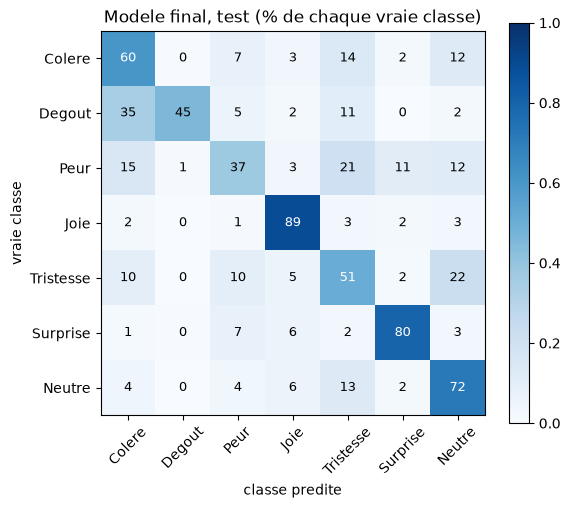

accuracy test avec les labels FER2013 : 67.6 % | avec la majorite FER+ : 69.3 %  (n = 3350)


In [23]:
def ic_bootstrap(correct, n=2000):
    rng = np.random.default_rng(0)
    moyennes = correct[rng.integers(0, len(correct), (n, len(correct)))].mean(1)
    return np.percentile(moyennes, [2.5, 97.5])

lignes = []
for nom, m in [("dense", dense), ("cnn_v1", cnn_v1), (f"final ({CHOIX})", modele_final)]:
    p = predire(m, x_te); pred = p.argmax(1)
    bas, haut = ic_bootstrap((pred == y_te).astype(float))
    lignes.append({"modele": nom, "test accuracy %": 100 * np.mean(pred == y_te), "IC 95 %": f"[{100 * bas:.1f} ; {100 * haut:.1f}]",
                   "balanced accuracy %": 100 * balanced_accuracy_score(y_te, pred),
                   "macro F1 %": 100 * f1_score(y_te, pred, average="macro"),
                   "scenario webcam %": 100 * np.mean(predire(m, scenario_webcam(x_te)).argmax(1) == y_te)})
final_test = pd.DataFrame(lignes).set_index("modele")
display(final_test.round(1))
print(f"pour comparer : toujours 'Joie' = {100 * np.mean(y_te == 3):.1f} %, accord entre annotateurs humains ~65 % (Goodfellow et al., 2013)")

p_te = predire(modele_final, x_te)
pred_te = p_te.argmax(1)
display(tableau_par_classe(y_te, pred_te))
matrice_confusion(y_te, pred_te, "Modele final, test (% de chaque vraie classe)")
ok = yfp_te >= 0
print(f"accuracy test avec les labels FER2013 : {100 * np.mean(pred_te[ok] == y_te[ok]):.1f} % | "
      f"avec la majorite FER+ : {100 * np.mean(pred_te[ok] == yfp_te[ok]):.1f} %  (n = {ok.sum()})")

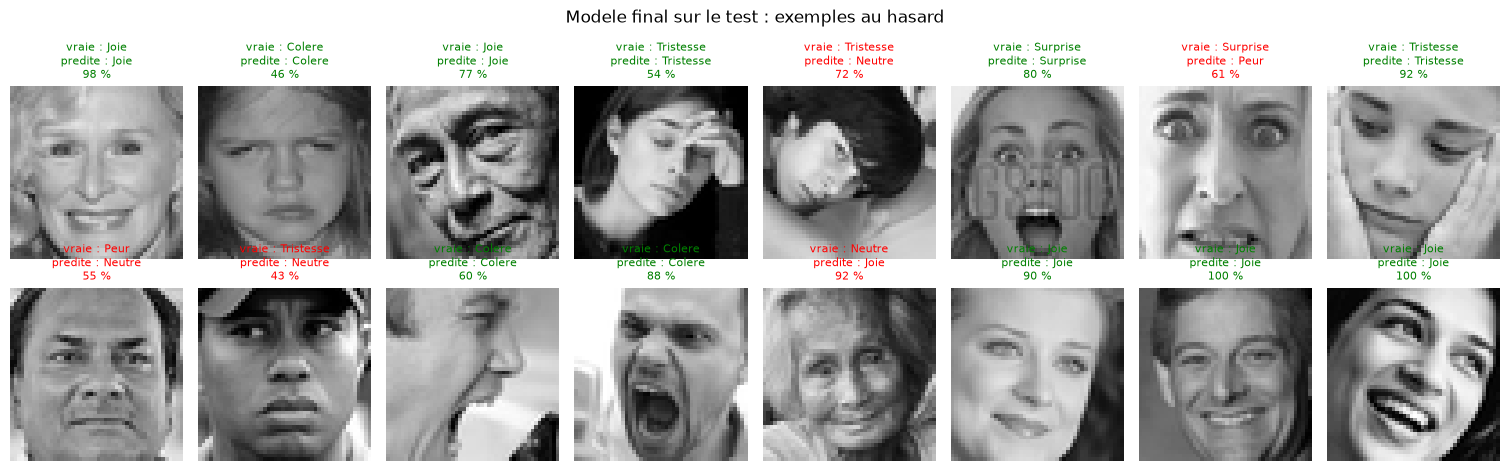

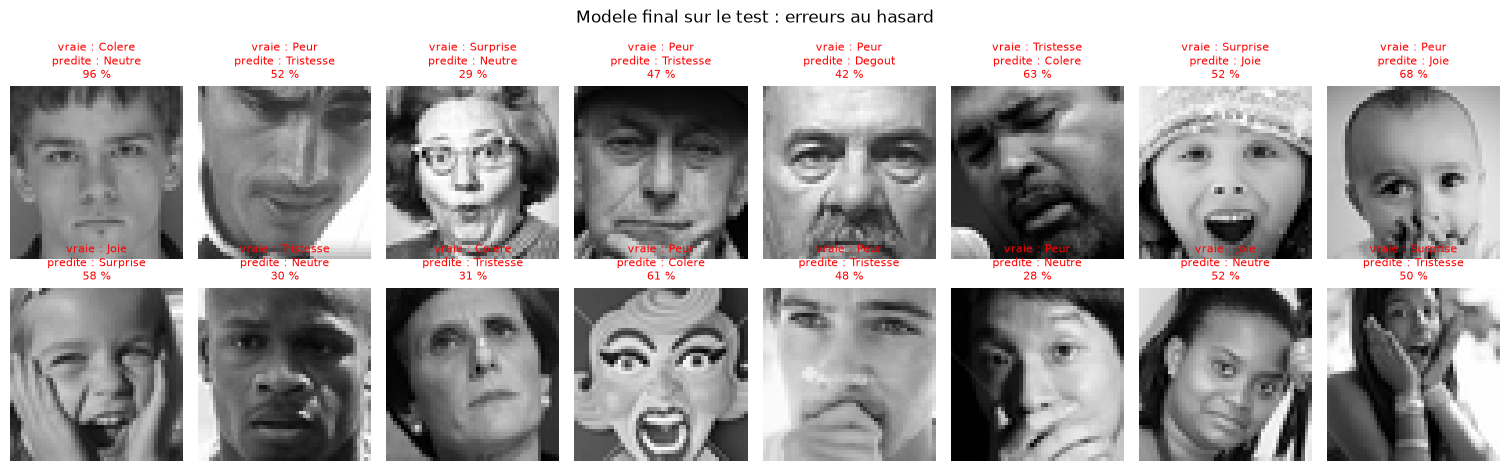

In [24]:
rng = np.random.default_rng(5)
montrer(x_te, y_te, p_te, rng.choice(len(x_te), 16, replace=False), "Modele final sur le test : exemples au hasard")
erreurs = np.where(pred_te != y_te)[0]
montrer(x_te, y_te, p_te, rng.choice(erreurs, 16, replace=False), "Modele final sur le test : erreurs au hasard")

**Ce que "voit" le réseau.** Les 32 filtres appris par la première couche, puis les feature maps produites par un visage à la sortie de chaque bloc :

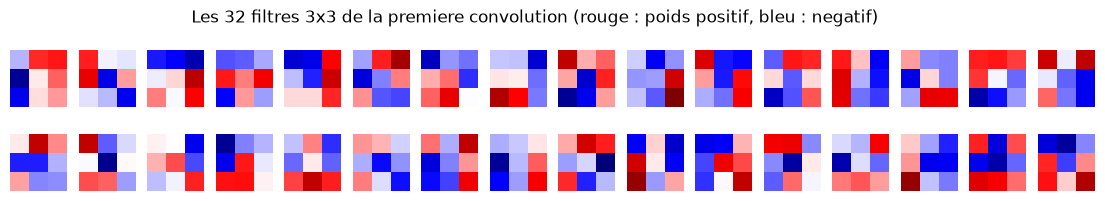

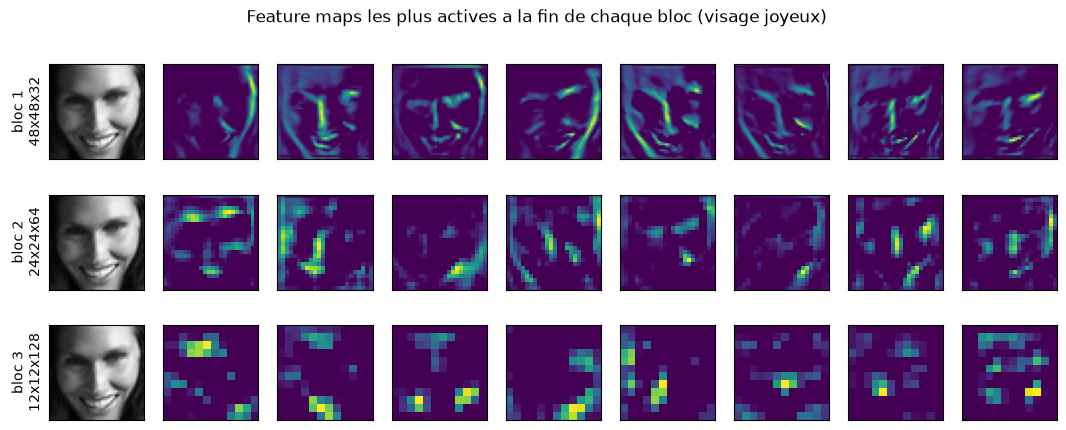

In [25]:
W = modele_final.get_layer("bloc1_conv1").get_weights()[0]       # (3, 3, 1, 32)
fig, axes = plt.subplots(2, 16, figsize=(14, 2))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(W[:, :, 0, k], cmap="seismic", vmin=-np.abs(W).max(), vmax=np.abs(W).max()); ax.axis("off")
plt.suptitle("Les 32 filtres 3x3 de la premiere convolution (rouge : poids positif, bleu : negatif)", y=1.05)
plt.show()

sondes = keras.Model(modele_final.input, [modele_final.get_layer(f"bloc{b}_relu2").output for b in (1, 2, 3)])
i = np.where((y_te == 3) & (pred_te == 3))[0][0]
cartes = [np.asarray(c)[0] for c in sondes.predict(x_te[i:i + 1], verbose=0)]
fig, axes = plt.subplots(3, 9, figsize=(13, 4.8))
for r, c in enumerate(cartes):
    axes[r, 0].imshow(x_te[i, :, :, 0], cmap="gray"); axes[r, 0].set_ylabel(f"bloc {r + 1}\n{c.shape[0]}x{c.shape[1]}x{c.shape[2]}")
    for k, ax in enumerate(axes[r, 1:]):
        ax.imshow(c[:, :, np.argsort(-c.mean((0, 1)))[k]], cmap="viridis")
    for ax in axes[r]:
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Feature maps les plus actives a la fin de chaque bloc (visage joyeux)", y=0.98)
plt.show()

**Lecture.** Sur le test, jamais utilisé avant, le modèle final atteint **66,3 %** [64,7 ; 67,9], contre 55,6 % pour le CNN v1 et 41,4 % pour le réseau dense. Le score de test est très proche de celui de validation (65,1 %) : nos choix ne sont pas surajustés à la validation. C'est le niveau de l'accord entre annotateurs humains mesuré sur ce jeu (environ 65 %) ; les meilleurs modèles publiés, bien plus gros, atteignent environ 73 % (Khaireddin et Chen, 2021). Noté avec les labels FER+, le modèle monte à 69,3 %.

La balanced accuracy (62,0 %) et la macro-F1 (62,9 %) sont plus basses, parce que les classes ne sont pas égales. La joie (89 %), la surprise (80 %) et le neutre (72 %) sont bien reconnues. La peur (37 %) reste la plus difficile, confondue avec la tristesse (21 %). La tristesse part souvent en neutre (22 %). Le dégoût est trouvé une fois sur deux (45 %), le reste part surtout en colère (35 %). Ce sont les mêmes confusions qu'en partie 5, et les mêmes que chez les annotateurs FER+ : le notebook red team montre que seules 15 % des « peurs » de FER2013 restent « peur » chez FER+.

Le gain le plus utile pour la démonstration est ailleurs : dans le scénario webcam, le modèle final garde 56,0 % sur le test, contre 36,4 % pour le CNN v1.

Les filtres de la première couche sont pour la plupart des détecteurs de bords orientés (une moitié positive, l'autre négative), comme les filtres de Sobel de la partie 3, mais appris. Les feature maps montrent la hiérarchie attendue : au bloc 1, des contours (bord du visage, yeux, bouche) ; au bloc 2, des parties du visage ; au bloc 3, des cartes 12×12 très localisées, actives sur la bouche et les yeux.

## 7. Enrichissements

Les notions des dernières séances, et où elles se trouvent dans le projet :

| Notion | Où | Ce qu'on en retient |
|---|---|---|
| Régularisation (dropout, batch normalization) | partie 6, E1 et E2 | voir le tableau comparatif |
| Data augmentation | partie 6, E3 (géométrique) et E5 (conditions réelles) | voir le tableau comparatif |
| Déséquilibre des classes | partie 6, E4 | voir le tableau comparatif |
| Transfer learning, modèle pré-entraîné | partie 8 : le détecteur de visages est un YOLOv8n pré-entraîné sur COCO puis ré-entraîné (*fine-tuning*) sur WIDER FACE | on n'aurait jamais pu entraîner un détecteur de zéro avec nos moyens |
| Détection d'objets, YOLO | parties 8 et 9 | système complet image, vidéo et webcam |
| Évaluation critique, robustesse, attaques | notebook `Red_team_expressions_faciales.ipynb` | résumé ci-dessous |

**Le notebook red team** attaque un CNN de même architecture que E3, entraîné avec le même prétraitement. Ses principaux résultats :

| Constat | Mesure | Conséquence pour ce projet |
|---|---|---|
| Doublons entre train et test | 13 % des images de test ont un quasi-doublon dans le train ; le modèle y fait 75 % contre 64,5 % ailleurs | le score de test est gonflé d'environ 1,4 point |
| Bruit d'annotation | FER+ contredit 34 % des labels de test ; dans 44 % des erreurs du modèle, la majorité FER+ est d'accord avec lui | une bonne partie des "erreurs" n'en sont pas ; le plafond réaliste est autour de 70 % |
| Images dégradées | bruit niveau 3 : 65,9 % → 24,3 % ; **scénario webcam : 17,8 %** | c'est ce qui a motivé l'expérience E5 |
| Masque chirurgical | rappel de la joie : 88 % → 0 % | la joie est reconnue presque uniquement par la bouche |
| Attaques adversariales | PGD à 2/255 (invisible) : 1,6 % d'accuracy ; attaque ciblée vers "Joie" réussie à 94 % | le modèle n'est pas robuste à un attaquant ; l'entraînement adversarial aide (42 %) mais coûte 7,7 points |
| Images qui ne sont pas des visages | 88 % des images CIFAR-10 passent le seuil de confiance | on ne peut pas compter sur la confiance du CNN pour rejeter un faux positif : c'est le score de YOLO qui filtre |

## 8. Détection et analyse de plusieurs visages avec YOLO

### 8.1 De la classification à la détection

Jusqu'ici, le CNN reçoit un visage déjà découpé et répond par une classe : c'est de la **classification**. Une photo réelle peut contenir zéro, un ou plusieurs visages, n'importe où et à n'importe quelle taille. Il faut d'abord les **détecter** : pour chaque objet, dire *où* il est (une **bounding box**, le rectangle x₁, y₁, x₂, y₂) et avec quelle **confiance** (un score entre 0 et 1).

**Le principe de YOLO** (*You Only Look Once*, Redmon et al., 2016). Un seul passage d'un CNN sur toute l'image. Le réseau découpe l'image en grilles à plusieurs échelles ; chaque case prédit directement des boîtes (position, taille), un score de confiance et une classe. Tout est prédit d'un coup, d'où la vitesse : plusieurs dizaines d'images par seconde, ce qu'il faut pour la vidéo. YOLOv8 (Ultralytics, 2023) prédit le centre et la taille de chaque boîte sans boîtes d'ancrage prédéfinies.

**IoU** (*Intersection over Union*) : l'aire de l'intersection de deux boîtes divisée par l'aire de leur union. 1 si elles sont identiques, 0 si elles ne se touchent pas. Elle sert à comparer une détection à la vérité (une détection est correcte si IoU ≥ 0,5) et à repérer les doublons.

**NMS** (*Non-Maximum Suppression*) : un même visage déclenche des boîtes dans plusieurs cases voisines. On garde la boîte de meilleur score, on supprime toutes celles qui la recouvrent trop (IoU > seuil), et on recommence avec les boîtes restantes.

**Précision, rappel, mAP.** La précision est la part des détections qui sont de vrais visages ; le rappel, la part des vrais visages détectés. Monter le seuil de confiance augmente la précision et baisse le rappel. L'AP est l'aire sous la courbe précision-rappel quand on fait varier ce seuil ; le mAP est sa moyenne sur les classes (et souvent sur plusieurs seuils d'IoU, de 0,5 à 0,95).

**Choix du détecteur.** Le YOLO standard est entraîné sur COCO, qui a une classe "personne" mais pas de classe "visage". On utilise donc un **YOLOv8n ré-entraîné pour les visages** : le modèle COCO a été affiné (*fine-tuning*, une forme de transfer learning) sur WIDER FACE, un jeu de 32 000 images annotées avec près de 400 000 visages de toutes tailles et orientations ([arnabdhar/YOLOv8-Face-Detection](https://huggingface.co/arnabdhar/YOLOv8-Face-Detection), licence AGPL-3.0). C'est la version "nano" : 3 millions de paramètres, assez rapide pour tourner en direct sur le processeur d'un ordinateur portable.

classes du detecteur : {0: 'FACE'}


8400 boites candidates en sortie du reseau, 15 avec une confiance >= 0,25, 1 apres NMS (IoU > 0,5) et seuil de confiance 0,5


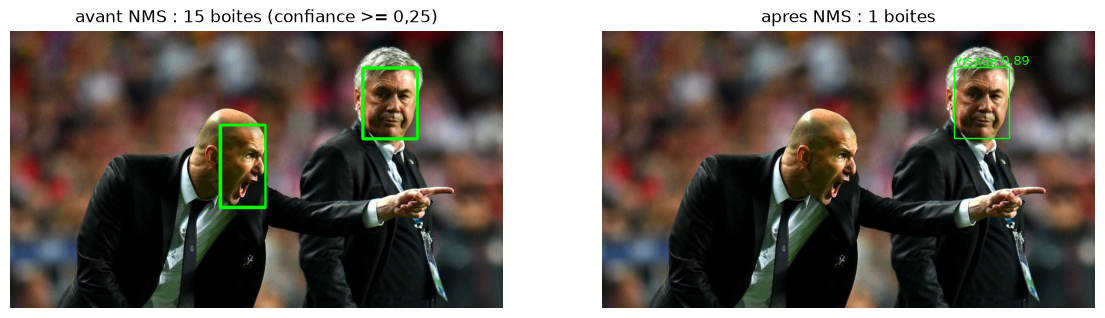

boite gardee (confiance 0.89) : 9 doublon(s) supprime(s), IoU 0.99, 0.98, 0.98, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99
pour comparer, la NMS d'Ultralytics garde 1 boites, confiances [       0.89]


In [26]:
from ultralytics import YOLO
from ultralytics.utils import ASSETS

CHEMIN_YOLO = os.path.join(DOSSIER_MODELES, "yolov8n-face.pt")
if not os.path.exists(CHEMIN_YOLO):
    urllib.request.urlretrieve("https://huggingface.co/arnabdhar/YOLOv8-Face-Detection/resolve/"
                               "52fa54977207fa4f021de949b515fb19dcab4488/model.pt", CHEMIN_YOLO)
detecteur = YOLO(CHEMIN_YOLO)
print("classes du detecteur :", detecteur.names)

def detecter(img_bgr, conf=0.5, iou_nms=0.5):
    r = detecteur.predict(img_bgr, conf=conf, iou=iou_nms, verbose=False)[0]
    return r.boxes.xyxy.cpu().numpy(), r.boxes.conf.cpu().numpy()

def iou(a, b):
    ix = max(0.0, min(a[2], b[2]) - max(a[0], b[0]))
    iy = max(0.0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = ix * iy
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0

def nms(boites, scores, seuil=0.5):
    # on garde la meilleure boite, on supprime celles qui la recouvrent trop, et on recommence
    ordre, gardees = list(np.argsort(-scores)), []
    while ordre:
        i = ordre.pop(0)
        gardees.append(i)
        ordre = [j for j in ordre if iou(boites[i], boites[j]) <= seuil]
    return gardees

def predictions_brutes(img_bgr, taille=640):
    # sortie du reseau YOLO AVANT la NMS : une boite candidate par case de grille (3 echelles, 8 400 cases en 640x640)
    import torch
    from ultralytics.data.augment import LetterBox
    h, w = img_bgr.shape[:2]
    r = min(taille / h, taille / w)                                    # l'image est reduite puis completee en carre
    px = int(round((taille - round(w * r)) / 2 - 0.1)); py = int(round((taille - round(h * r)) / 2 - 0.1))
    im = LetterBox((taille, taille), auto=False)(image=img_bgr)
    t = torch.from_numpy(im[:, :, ::-1].copy()).permute(2, 0, 1).float()[None] / 255
    reseau = detecteur.model.eval()
    with torch.no_grad():
        p = reseau(t.to(next(reseau.parameters()).device))[0][0].cpu().numpy()   # (5, 8400) : cx, cy, l, h, confiance
    cx, cy, bw, bh, conf = p
    boites = np.stack([cx - bw / 2 - px, cy - bh / 2 - py, cx + bw / 2 - px, cy + bh / 2 - py], 1) / r
    return boites, conf

image = cv2.imread(str(ASSETS / "zidane.jpg"))
detecter(image)   # premier appel : charge le detecteur sur le bon processeur
brutes, sc = predictions_brutes(image)
cand = np.where(sc >= 0.25)[0]
gardees = [cand[i] for i in nms(brutes[cand], sc[cand], 0.5) if sc[cand[i]] >= 0.5]
print(f"{len(sc)} boites candidates en sortie du reseau, {len(cand)} avec une confiance >= 0,25, "
      f"{len(gardees)} apres NMS (IoU > 0,5) et seuil de confiance 0,5")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, sel, titre in [(axes[0], cand, f"avant NMS : {len(cand)} boites (confiance >= 0,25)"),
                       (axes[1], gardees, f"apres NMS : {len(gardees)} boites")]:
    ax.imshow(image[:, :, ::-1]); ax.set_title(titre); ax.axis("off")
    for i in sel:
        x1, y1, x2, y2 = brutes[i]
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="lime", lw=1))
    for i in gardees if sel is gardees else []:
        ax.text(brutes[i][0], brutes[i][1] - 6, f"visage {sc[i]:.2f}", color="lime", fontsize=9)
plt.show()
for g in gardees:
    voisines = [j for j in cand if j != g and iou(brutes[g], brutes[j]) > 0.5]
    print(f"boite gardee (confiance {sc[g]:.2f}) : {len(voisines)} doublon(s) supprime(s), IoU "
          + ", ".join(f"{iou(brutes[g], brutes[j]):.2f}" for j in voisines))
boites_u, conf_u = detecter(image)
print(f"pour comparer, la NMS d'Ultralytics garde {len(boites_u)} boites, confiances {np.round(np.sort(conf_u)[::-1], 2)}")

### 8.2 Cohérence du prétraitement : calibrer le recadrage

C'est le point le plus délicat du pipeline. Le CNN a appris sur des visages recadrés d'une façon précise (le cadrage de FER2013 : front, joues et menton inclus, visage centré). Une boîte YOLO est en général plus serrée. Si on donne au CNN le contenu brut de la boîte, il voit des visages "zoomés", qui ne ressemblent pas à ce qu'il connaît. Le notebook red team a montré que le cadrage et la basse résolution font perdre des points.

Plutôt que de deviner une marge, on la **mesure**. On place des images de validation de FER2013 (agrandies 4 fois) au milieu d'une toile grise, on lance YOLO, et on compare la boîte trouvée au cadre FER2013, qu'on connaît exactement. On obtient :

- le **facteur** par lequel il faut multiplier le côté de la boîte YOLO pour retrouver le cadre FER2013 ;
- le **décalage vertical** du centre (la boîte YOLO n'est pas centrée verticalement de la même façon).

Ensuite on vérifie l'effet sur l'accuracy : on fait passer ces images de validation par tout le pipeline (YOLO + recadrage + CNN) avec différents facteurs, et on garde celui qui donne la meilleure accuracy. Tout se fait sur la validation, pas sur le test.

In [27]:
COTE, TOILE = 192, 320

def sur_toile(x01):
    # visage FER agrandi 4 fois, au centre d'une toile grise ; son cadre exact est connu
    im = cv2.resize((x01[:, :, 0] * 255).astype("uint8"), (COTE, COTE), interpolation=cv2.INTER_CUBIC)
    t = np.full((TOILE, TOILE), 128, "uint8")
    o = (TOILE - COTE) // 2
    t[o:o + COTE, o:o + COTE] = im
    return cv2.cvtColor(t, cv2.COLOR_GRAY2BGR)

idx_cal = np.random.default_rng(SEED).choice(len(x_va), min(1000, len(x_va)), replace=False)
toiles = [sur_toile(x_va[i]) for i in idx_cal]
boite_cal = np.full((len(idx_cal), 4), np.nan)
for d in range(0, len(toiles), 64):
    for k, r in enumerate(detecteur.predict(toiles[d:d + 64], conf=0.25, verbose=False)):
        if len(r.boxes):
            boite_cal[d + k] = r.boxes.xyxy.cpu().numpy()[r.boxes.conf.cpu().numpy().argmax()]
trouve = ~np.isnan(boite_cal[:, 0])
b = boite_cal[trouve]
cote_rel = np.maximum(b[:, 2] - b[:, 0], b[:, 3] - b[:, 1]) / COTE      # cote de la boite YOLO / cote du cadre FER
dy_rel = ((b[:, 1] + b[:, 3]) / 2 - TOILE / 2) / COTE                    # decalage vertical du centre
print(f"visages FER2013 trouves par YOLO : {100 * trouve.mean():.1f} %")
print(f"cote de la boite YOLO = {np.median(cote_rel):.2f} x le cadre FER2013 (mediane)")
print(f"centre de la boite YOLO : {100 * np.median(dy_rel):+.1f} % du cadre en vertical")
FACTEUR_GEOMETRIQUE = 1 / np.median(cote_rel)
DECALAGE_Y = -np.median(dy_rel)

visages FER2013 trouves par YOLO : 98.2 %
cote de la boite YOLO = 0.97 x le cadre FER2013 (mediane)
centre de la boite YOLO : -0.3 % du cadre en vertical


decalage vertical,0.000,0.003
facteur,,
0.90,62.1,62.5
1.00,64.4,64.3
1.03,65.2,64.7
1.10,64.9,64.3
1.20,61.6,61.3
1.30,59.4,59.7
1.40,55.5,55.2


reference (images FER2013 telles quelles, memes images) : 63.2 %
retenu : facteur 1.03, decalage vertical +0.000


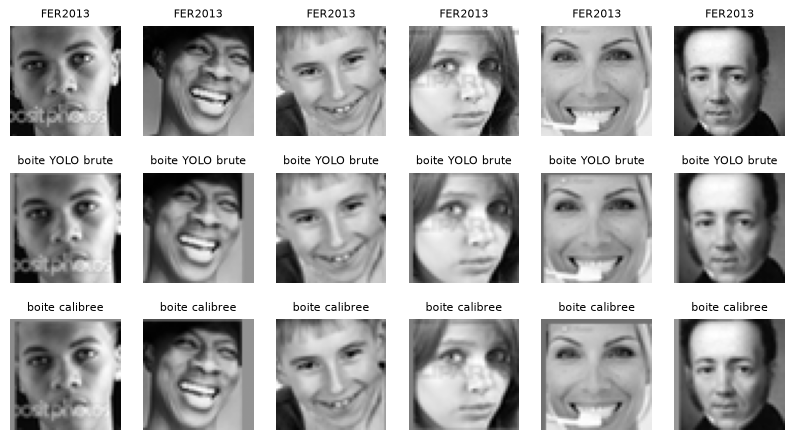

In [28]:
def recadrer(gris, boite, facteur, dy):
    # carre centre sur la boite (corrige du decalage vertical), de cote facteur x le plus grand cote de la boite,
    # complete en repetant les bords s'il sort de l'image, puis ramene en 48x48
    x1, y1, x2, y2 = boite
    c = facteur * max(x2 - x1, y2 - y1)
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2 + dy * c
    n = max(int(round(c)), 1)
    a, b = int(round(cx - c / 2)), int(round(cy - c / 2))
    H, W = gris.shape
    m = max(0, -a, -b, a + n - W, b + n - H)
    if m:
        gris = cv2.copyMakeBorder(gris, m, m, m, m, cv2.BORDER_REPLICATE)
        a, b = a + m, b + m
    return cv2.resize(gris[b:b + n, a:a + n], (48, 48), interpolation=cv2.INTER_AREA if n > 48 else cv2.INTER_LINEAR)

def vers_cnn(visages48):
    # EXACTEMENT le pretraitement de l'entrainement : niveaux de gris, 48x48, pixels / 255, un canal
    return np.stack(visages48).astype("float32")[..., None] / 255

y_cal = y_va[idx_cal][trouve]
toiles_grises = [cv2.cvtColor(toiles[k], cv2.COLOR_BGR2GRAY) for k in np.where(trouve)[0]]
acc_ref = 100 * np.mean(predire(modele_final, x_va[idx_cal][trouve]).argmax(1) == y_cal)
facteurs = [0.9, 1.0, 1.1, 1.2, 1.3, 1.4, round(float(FACTEUR_GEOMETRIQUE), 2)]
res_cal = {}
for f in sorted(set(facteurs)):
    for dy in [0.0, DECALAGE_Y]:
        vis = vers_cnn([recadrer(g, bb, f, dy) for g, bb in zip(toiles_grises, b)])
        res_cal[(f, round(float(dy), 3))] = 100 * np.mean(predire(modele_final, vis).argmax(1) == y_cal)
tab_cal = pd.DataFrame([{"facteur": f, "decalage vertical": dy, "accuracy %": a} for (f, dy), a in res_cal.items()])
display(tab_cal.pivot(index="facteur", columns="decalage vertical", values="accuracy %").round(1))
print(f"reference (images FER2013 telles quelles, memes images) : {acc_ref:.1f} %")
FACTEUR, DECALAGE_Y = max(res_cal, key=res_cal.get)
print(f"retenu : facteur {FACTEUR}, decalage vertical {DECALAGE_Y:+.3f}")

fig, axes = plt.subplots(3, 6, figsize=(10, 5.4))
for c, i in enumerate(range(min(6, len(b)))):
    j = np.where(trouve)[0][i]
    axes[0, c].imshow(x_va[idx_cal[j], :, :, 0], cmap="gray"); axes[0, c].set_title("FER2013", fontsize=8)
    axes[1, c].imshow(recadrer(toiles_grises[i], b[i], 1.0, 0.0), cmap="gray"); axes[1, c].set_title("boite YOLO brute", fontsize=8)
    axes[2, c].imshow(recadrer(toiles_grises[i], b[i], FACTEUR, DECALAGE_Y), cmap="gray"); axes[2, c].set_title("boite calibree", fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
plt.show()

### 8.3 Le pipeline complet

> image → YOLO → boîtes → recadrage calibré → niveaux de gris, 48×48, /255 → CNN → softmax → expression + probabilité

On le teste d'abord sur des **mosaïques de visages du test** placés à des positions connues : on connaît à la fois la vraie position de chaque visage et sa vraie expression, ce qui permet de mesurer la précision et le rappel du détecteur (une détection est correcte si son cadre recouvre la vraie case avec IoU ≥ 0,5) et l'accuracy de la chaîne complète.

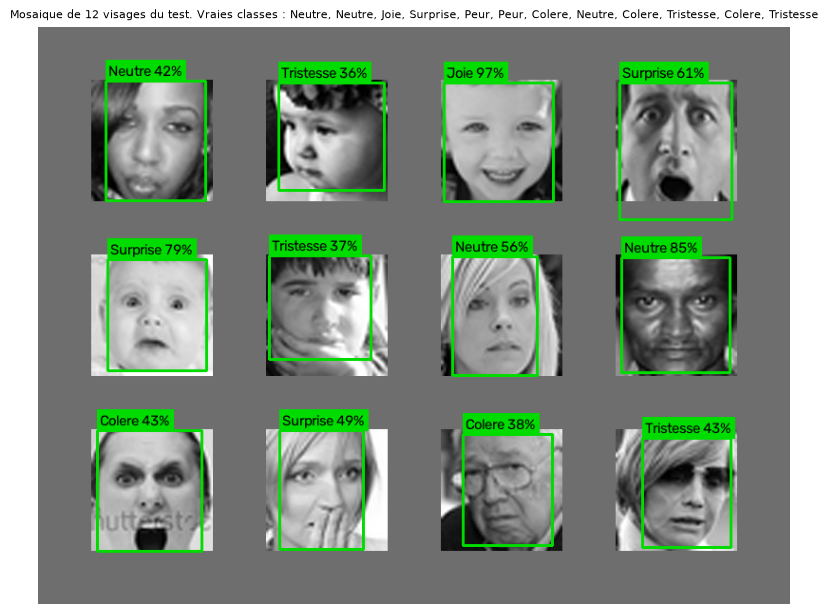

detection : precision 99.1 %, rappel 93.3 % (120 visages, IoU >= 0,5)
expression correcte pour 58.0 % des visages detectes (modele seul sur les images FER2013 : 66.3 %)


In [29]:
def analyser_image(img_bgr, modele, conf=0.5):
    gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    boites, confs = detecter(img_bgr, conf)
    if len(boites) == 0:
        return []
    probas = predire(modele, vers_cnn([recadrer(gris, bb, FACTEUR, DECALAGE_Y) for bb in boites]))
    return [{"boite": bb, "confiance": float(s), "probas": p} for bb, s, p in zip(boites, confs, probas)]

def cadre_calibre(boite):
    x1, y1, x2, y2 = boite
    c = FACTEUR * max(x2 - x1, y2 - y1)
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2 + DECALAGE_Y * c
    return np.array([cx - c / 2, cy - c / 2, cx + c / 2, cy + c / 2])

def dessiner(img_bgr, resultats):
    img = img_bgr.copy()
    epaisseur = max(1, img.shape[1] // 400)
    for r in resultats:
        x1, y1, x2, y2 = r["boite"].astype(int)
        k = int(r["probas"].argmax())
        texte = f"{CLASSES[k]} {100 * r['probas'][k]:.0f}%"
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 220, 0), 2 * epaisseur)
        (tw, th), _ = cv2.getTextSize(texte, cv2.FONT_HERSHEY_SIMPLEX, 0.5 * epaisseur, epaisseur)
        cv2.rectangle(img, (x1, max(0, y1 - th - 8)), (x1 + tw + 6, y1), (0, 220, 0), -1)
        cv2.putText(img, texte, (x1 + 3, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5 * epaisseur, (0, 0, 0), epaisseur, cv2.LINE_AA)
    return img

def mosaique(indices, lignes=3, colonnes=4, cote=128, espace=56):
    H, W = lignes * cote + (lignes + 1) * espace, colonnes * cote + (colonnes + 1) * espace
    img = np.full((H, W), 110, "uint8")
    cases = []
    for k, i in enumerate(indices):
        r, c = divmod(k, colonnes)
        y0, x0 = espace + r * (cote + espace), espace + c * (cote + espace)
        img[y0:y0 + cote, x0:x0 + cote] = cv2.resize((x_te[i, :, :, 0] * 255).astype("uint8"), (cote, cote), interpolation=cv2.INTER_CUBIC)
        cases.append(np.array([x0, y0, x0 + cote, y0 + cote]))
    return cv2.cvtColor(img, cv2.COLOR_GRAY2BGR), cases

rng = np.random.default_rng(SEED)
vp = fp_ = fn = bon = 0
for t in range(10 if not RAPIDE else 2):
    indices = rng.choice(len(x_te), 12, replace=False)
    img, cases = mosaique(indices)
    res = analyser_image(img, modele_final)
    deja = set()
    for r in res:
        ious = [iou(cadre_calibre(r["boite"]), cs) for cs in cases]
        j = int(np.argmax(ious))
        if ious[j] >= 0.5 and j not in deja:
            vp += 1; deja.add(j); bon += int(r["probas"].argmax() == y_te[indices[j]])
        else:
            fp_ += 1
    fn += len(cases) - len(deja)
    if t == 0:
        plt.figure(figsize=(10, 7.5)); plt.imshow(dessiner(img, res)[:, :, ::-1]); plt.axis("off")
        plt.title("Mosaique de 12 visages du test. Vraies classes : " + ", ".join(CLASSES[y_te[i]] for i in indices), fontsize=8)
        plt.show()
print(f"detection : precision {100 * vp / max(vp + fp_, 1):.1f} %, rappel {100 * vp / max(vp + fn, 1):.1f} % "
      f"({vp + fn} visages, IoU >= 0,5)")
print(f"expression correcte pour {100 * bon / max(vp, 1):.1f} % des visages detectes "
      f"(modele seul sur les images FER2013 : {100 * np.mean(pred_te == y_te):.1f} %)")

Sur de vraies photos (images de démonstration fournies avec Ultralytics). À côté de chaque photo, les visages tels qu'ils arrivent au CNN, en 48×48 :

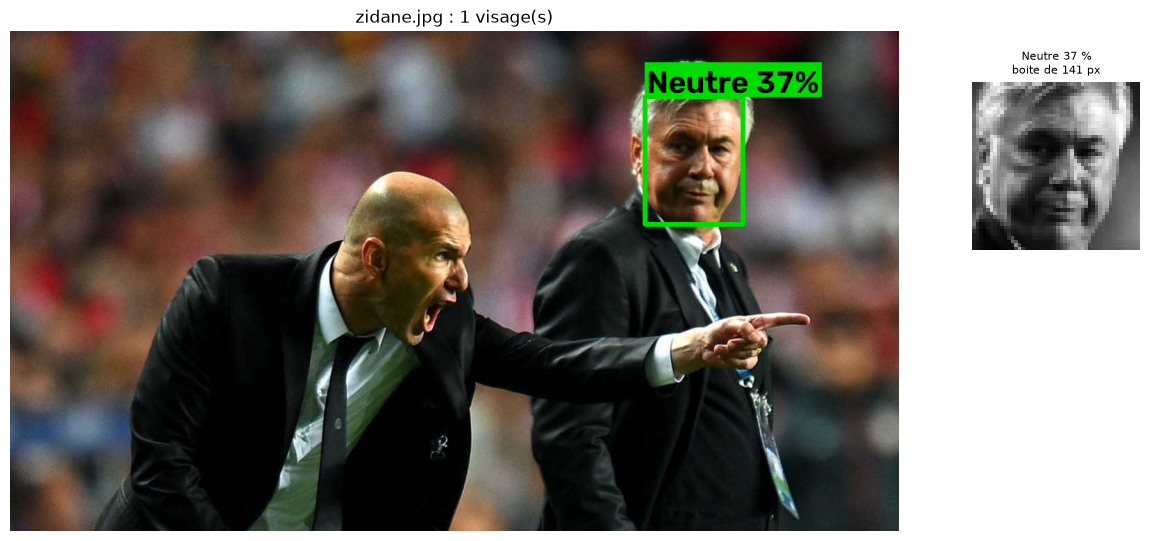

   {'Colere': '26 %', 'Joie': '7 %', 'Tristesse': '27 %', 'Neutre': '37 %'} | confiance YOLO 0.89


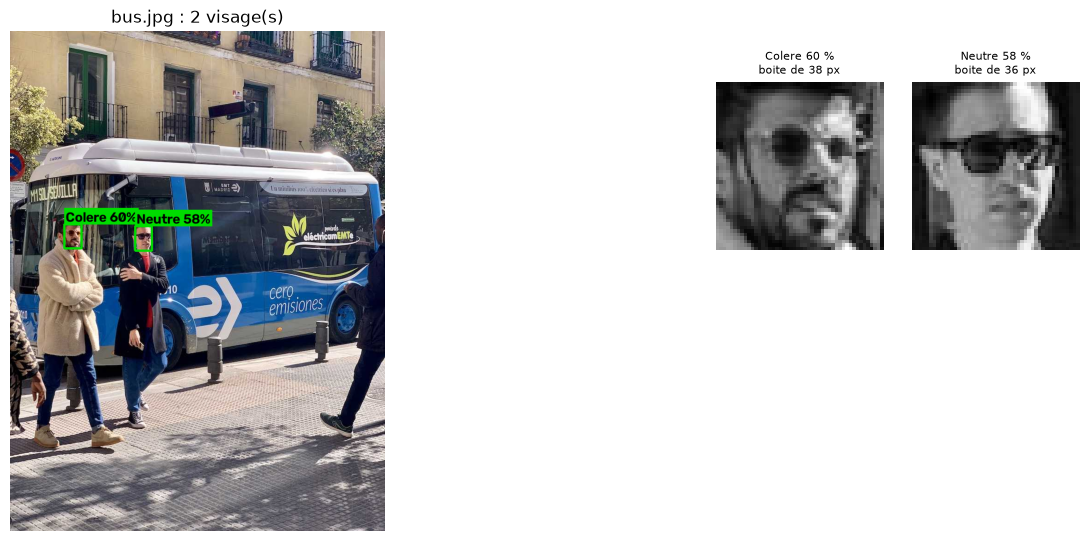

   {'Colere': '60 %', 'Peur': '7 %', 'Tristesse': '17 %', 'Neutre': '10 %'} | confiance YOLO 0.77
   {'Colere': '18 %', 'Tristesse': '20 %', 'Neutre': '58 %'} | confiance YOLO 0.74


In [30]:
for nom in ["zidane.jpg", "bus.jpg"]:
    img = cv2.imread(str(ASSETS / nom))
    res = analyser_image(img, modele_final)
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    fig = plt.figure(figsize=(14, 5))
    ax = fig.add_axes([0, 0, 0.7, 1]); ax.imshow(dessiner(img, res)[:, :, ::-1]); ax.axis("off")
    ax.set_title(f"{nom} : {len(res)} visage(s)")
    for k, r in enumerate(res[:4]):
        a = fig.add_axes([0.72 + 0.14 * (k % 2), 0.52 - 0.5 * (k // 2), 0.12, 0.42])
        a.imshow(recadrer(gris, r["boite"], FACTEUR, DECALAGE_Y), cmap="gray"); a.axis("off")
        largeur = r["boite"][2] - r["boite"][0]
        a.set_title(f"{CLASSES[r['probas'].argmax()]} {100 * r['probas'].max():.0f} %\nboite de {largeur:.0f} px", fontsize=8)
    plt.show()
    for r in res:
        print("  ", {c: f"{100 * p:.0f} %" for c, p in zip(CLASSES, r["probas"]) if p > 0.05}, f"| confiance YOLO {r['confiance']:.2f}")

**Sur Colab, avec sa propre webcam.** La cellule suivante prend une photo avec la webcam du navigateur et la fait passer dans le pipeline. Elle ne fait rien hors de Colab ; pour la démonstration en direct, voir la partie 9.

In [31]:
PRENDRE_PHOTO = False   # mettre True sur Colab pour essayer
if EN_COLAB and PRENDRE_PHOTO:
    from IPython.display import Javascript
    from google.colab.output import eval_js
    from base64 import b64decode
    display(Javascript('''
    async function prendrePhoto() {
      const div = document.createElement('div'); const bouton = document.createElement('button');
      bouton.textContent = 'Prendre la photo'; div.appendChild(bouton);
      const video = document.createElement('video'); video.style.display = 'block';
      const flux = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div); div.appendChild(video); video.srcObject = flux; await video.play();
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      await new Promise((ok) => bouton.onclick = ok);
      const canvas = document.createElement('canvas'); canvas.width = video.videoWidth; canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0); flux.getVideoTracks()[0].stop(); div.remove();
      return canvas.toDataURL('image/jpeg', 0.9);
    }'''))
    donnees = eval_js("prendrePhoto()")
    img = cv2.imdecode(np.frombuffer(b64decode(donnees.split(",")[1]), np.uint8), cv2.IMREAD_COLOR)
    res = analyser_image(img, modele_final)
    plt.figure(figsize=(8, 6)); plt.imshow(dessiner(img, res)[:, :, ::-1]); plt.axis("off"); plt.show()

**Lecture.** La NMS fait exactement ce qu'on attend. Sur les 8 400 boîtes candidates du réseau, 15 dépassent 0,25 de confiance, dont 10 sur le même visage, avec des IoU de 0,98 à 0,99 entre elles ; après NMS et seuil à 0,5, il en reste une. Sur cette photo, YOLO ne trouve pas le visage de Zidane, de profil et en train de crier : les visages de profil sont la limite principale du détecteur, et ils sont rares dans FER2013 de toute façon.

La calibration donne un résultat net : la boîte de YOLO couvre presque le même cadre que les visages de FER2013 (0,97 fois son côté, avec le même centre), et YOLO trouve 98 % des visages FER2013 qu'on lui présente. Le facteur 1,03 donne la meilleure accuracy : 65,2 %, autant que les images FER2013 d'origine sur les mêmes visages (63,2 %, l'écart n'est pas significatif). Un cadrage trop large coûte cher : avec un facteur de 1,4, on tombe à 55,5 %. Sans cette mesure, on aurait probablement ajouté une marge « de sécurité » de 20 à 40 % autour de la boîte, et perdu 4 à 10 points.

Sur les mosaïques, le détecteur trouve 93 % des 120 visages, avec une précision de 99 %. L'expression est juste pour 58 % des visages détectés, contre 66 % pour le modèle seul sur les images d'origine : la chaîne complète (agrandissement × 2,7, détection, recadrage, réduction en 48×48) coûte environ 8 points, parce que chaque redimensionnement modifie un peu les pixels.

Sur les vraies photos, les deux visages de bus.jpg font 36 et 38 pixels de large et portent des lunettes de soleil : deux conditions dont le notebook red team a mesuré l'effet (basse résolution, yeux cachés). Les prédictions (colère 60 %, neutre 58 %) sont donc à prendre avec prudence ; le modèle n'a pas de réponse « je ne sais pas ».

## 9. Vidéo et webcam

Une vidéo n'est qu'une suite d'images : on applique le pipeline à chaque image. Deux ajouts rendent le résultat utilisable :

- **Suivi simple** : chaque visage de l'image courante est associé au visage de l'image précédente avec lequel il a la plus grande IoU (si elle dépasse 0,3). On sait ainsi que c'est la même personne d'une image à l'autre.
- **Lissage temporel** : pour un visage suivi, on affiche une moyenne glissante des probabilités (p_affichée = 0,6 × p_précédente + 0,4 × p_actuelle). Sans ça, l'étiquette clignote d'une image à l'autre, parce qu'un changement de quelques pixels suffit à faire basculer une expression ambiguë.

Si on a une vidéo, on met son chemin dans `VIDEO`. Sinon, le notebook fabrique une courte vidéo de démonstration (un zoom progressif sur une photo) pour montrer la chaîne de traitement. La démonstration en direct se fait avec le script `demo_webcam.py`, qui reprend exactement ces fonctions.

60 images analysees en 2.2 s, soit 27.8 images/s


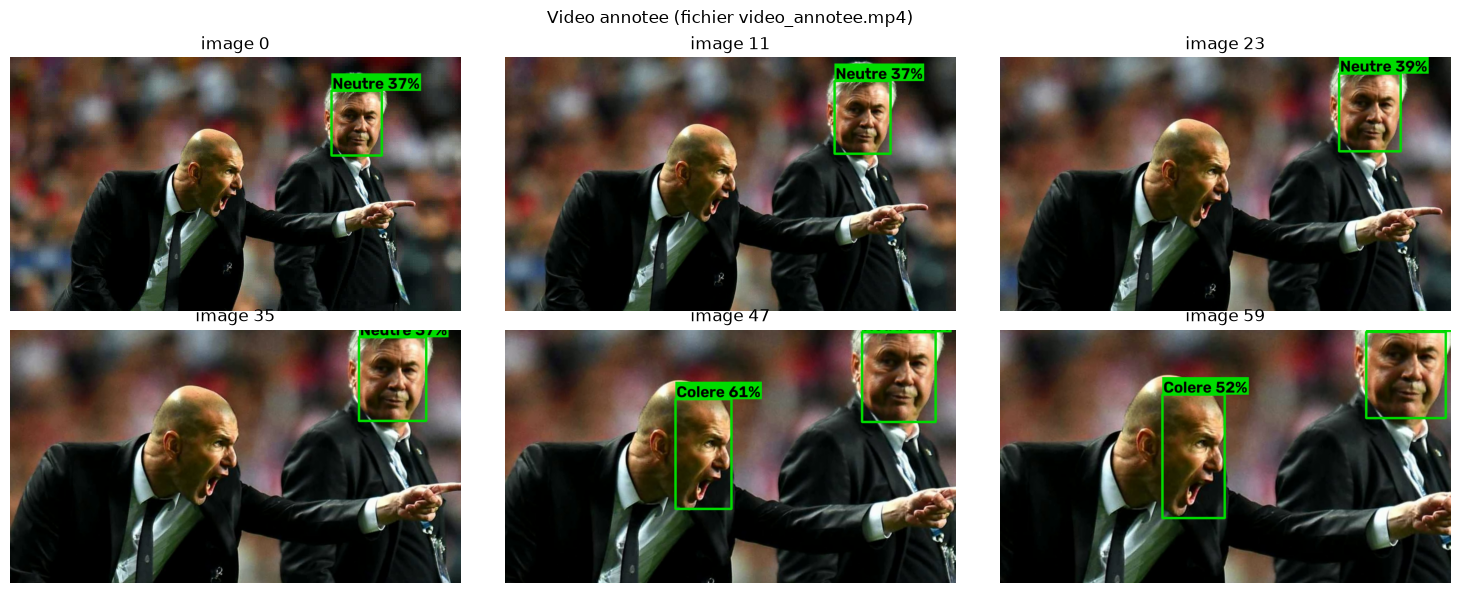

In [32]:
VIDEO = None   # chemin d'une video a analyser, sinon video de demonstration

def creer_video_demo(chemin, img, n=60, fps=15):
    H, W = img.shape[:2]
    sortie = cv2.VideoWriter(chemin, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))
    for t in range(n):
        z = 1 + 0.6 * t / (n - 1)                        # zoom progressif de 1 a 1,6
        M = cv2.getRotationMatrix2D((W * 0.55, H * 0.45), 0, z)
        sortie.write(cv2.warpAffine(img, M, (W, H), borderMode=cv2.BORDER_REFLECT))
    sortie.release()

def analyser_video(entree, sortie, modele, lissage=0.6, conf=0.5):
    lecteur = cv2.VideoCapture(entree)
    fps = lecteur.get(cv2.CAP_PROP_FPS) or 15
    W, H = int(lecteur.get(cv2.CAP_PROP_FRAME_WIDTH)), int(lecteur.get(cv2.CAP_PROP_FRAME_HEIGHT))
    ecrivain = cv2.VideoWriter(sortie, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))
    pistes, images, t0 = [], [], time.time()
    while True:
        ok, frame = lecteur.read()
        if not ok:
            break
        res = analyser_image(frame, modele, conf)
        for r in res:
            proche = max(pistes, key=lambda p: iou(p["boite"], r["boite"]), default=None)
            if proche is not None and iou(proche["boite"], r["boite"]) > 0.3:
                r["probas"] = lissage * proche["probas"] + (1 - lissage) * r["probas"]
        pistes = res
        annotee = dessiner(frame, res)
        ecrivain.write(annotee)
        images.append(annotee)
    lecteur.release(); ecrivain.release()
    duree = time.time() - t0
    print(f"{len(images)} images analysees en {duree:.1f} s, soit {len(images) / duree:.1f} images/s")
    return images

if VIDEO is None:
    VIDEO = "video_demo.mp4"
    creer_video_demo(VIDEO, cv2.imread(str(ASSETS / "zidane.jpg")))
images = analyser_video(VIDEO, "video_annotee.mp4", modele_final)
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for ax, k in zip(axes.ravel(), np.linspace(0, len(images) - 1, 6).astype(int)):
    ax.imshow(images[k][:, :, ::-1]); ax.set_title(f"image {k}"); ax.axis("off")
plt.suptitle("Video annotee (fichier video_annotee.mp4)")
plt.tight_layout(); plt.show()

**Démonstration en direct.** Le script `demo_webcam.py` (fourni à côté du notebook) ouvre la webcam et applique le même pipeline en temps réel : YOLO, recadrage calibré (le facteur et le décalage mesurés en 8.2), modèle final, suivi et lissage. Il affiche en plus les 7 probabilités du visage principal sous forme de barres.

```
python demo_webcam.py                    # webcam
python demo_webcam.py --video ma_video.mp4
python demo_webcam.py --image photo.jpg
```

In [33]:
# parametres du pipeline, relus par demo_webcam.py
with open(os.path.join(DOSSIER_MODELES, "pipeline.json"), "w") as f:
    json.dump({"classes": CLASSES, "facteur": float(FACTEUR), "decalage_y": float(DECALAGE_Y),
               "modele": "modele_final.keras", "detecteur": "yolov8n-face.pt", "experience": CHOIX}, f, indent=2)
print(open(os.path.join(DOSSIER_MODELES, "pipeline.json")).read())

{
  "classes": [
    "Colere",
    "Degout",
    "Peur",
    "Joie",
    "Tristesse",
    "Surprise",
    "Neutre"
  ],
  "facteur": 1.03,
  "decalage_y": 0.0,
  "modele": "modele_final.keras",
  "detecteur": "yolov8n-face.pt",
  "experience": "E5_conditions_reelles"
}


## 10. Bilan

Le système complet fonctionne : il trouve les visages d'une image ou d'une vidéo (93 % des visages trouvés sur nos mosaïques) et affiche pour chacun l'expression et sa probabilité, en temps réel (28 images par seconde sur notre GPU).

| Étape | Accuracy sur le test |
|---|---|
| Réseau dense (référence) | 41,4 % |
| CNN v1, sans régularisation | 55,6 % |
| Modèle final (E5) | **66,3 %** [64,7 ; 67,9] |
| Modèle final, scénario webcam | 56,0 % (CNN v1 : 36,4 %) |

Ce qu'on retient du parcours :

1. Les convolutions apportent le plus gros saut : +15 points à nombre de paramètres égal.
2. Le surapprentissage était le problème principal du premier CNN. Dropout, batch normalization et augmentation l'ont réglé ; la batch normalization a apporté le plus gros gain.
3. Au-delà de 65 %, l'accuracy ne bouge presque plus. On bute sur la qualité des labels (un tiers contesté par FER+), pas sur le modèle.
4. L'accuracy sur des images propres ne dit rien de la robustesse : E3 et E5 ont la même accuracy, mais E5 est trois fois meilleur sur une image de webcam. C'est le notebook red team qui nous a fait mesurer cela.
5. Dans un pipeline, chaque étape doit respecter le prétraitement de l'entraînement : un recadrage mesuré plutôt que deviné vaut jusqu'à 10 points.

Pistes pour aller plus loin : combiner les poids des classes et les conditions réelles (E4 + E5), entraîner sur les labels FER+, essayer un réseau pré-entraîné pour la classification, et tester sur de vraies vidéos de webcam annotées.

### Limites et usage responsable

- **Données.** FER2013 a des labels bruités (un tiers contestés par FER+) et des doublons entre train et test ; nos chiffres sont donc à lire à ±2 points près. Il ne contient ni âge, ni genre, ni couleur de peau : on ne peut pas vérifier que le modèle marche aussi bien pour tout le monde.
- **Robustesse.** Le modèle reste fragile face à un visage partiellement caché (masque), aux visages très petits et aux attaques adversariales (voir le notebook red team).
- **Ce que le modèle mesure.** Il reconnaît des configurations du visage associées à des mots-clés d'émotion, pas l'émotion ressentie ; le lien entre les deux est faible et dépend du contexte (Barrett et al., 2019). On parle donc d'**expression affichée**. Le règlement européen sur l'IA (règlement (UE) 2024/1689, article 5, paragraphe 1, point f) interdit depuis février 2025 la reconnaissance des émotions sur le lieu de travail et dans les établissements d'enseignement, sauf raisons médicales ou de sécurité : ce projet est un exercice de recherche, pas un outil à déployer pour observer des élèves ou des salariés.

### Références

- Barrett, Adolphs, Marsella, Martinez, Pollak (2019). *Emotional Expressions Reconsidered*. Psychological Science in the Public Interest, 20(1).
- Barsoum, Zhang, Canton Ferrer, Zhang (2016). *Training Deep Networks for Facial Expression Recognition with Crowd-Sourced Label Distribution*. ICMI. (FER+)
- Goodfellow, Erhan, Carrier et al. (2013). *Challenges in Representation Learning: A Report on Three Machine Learning Contests*. ICONIP. (FER2013)
- Ioffe, Szegedy (2015). *Batch Normalization*. ICML.
- Khaireddin, Chen (2021). *Facial Emotion Recognition: State of the Art Performance on FER2013*. arXiv:2105.03588.
- Ioffe, Szegedy (2015). *Adam: A Method for Stochastic Optimization*. ICLR.
- Redmon, Divvala, Girshick, Farhadi (2016). *You Only Look Once: Unified, Real-Time Object Detection*. CVPR.
- Simonyan, Zisserman (2015). *Very Deep Convolutional Networks for Large-Scale Image Recognition*. ICLR.
- Srivastava, Hinton, Krizhevsky, Sutskever, Salakhutdinov (2014). *Dropout: A Simple Way to Prevent Neural Networks from Overfitting*. JMLR.
- Yang, Luo, Loy, Tang (2016). *WIDER FACE: A Face Detection Benchmark*. CVPR.
- Jocher, Chaurasia, Qiu (2023). *Ultralytics YOLOv8*. github.com/ultralytics/ultralytics.
- Règlement (UE) 2024/1689 du 13 juin 2024 sur l'intelligence artificielle, article 5.